#Executive Summary

This is an Exploratory Data Analysis on our New Organizations from January 2026, along with all Users and Events for those organizations through mid-April. Data was generated synthetically to simulate CRM and product telemetry exports.

#####Scope of Work:
- Validated data quality and table usability across Organizations, Users, and Events
- Cleaned source tables for downstream analysis
- Verified relational consistency across all three datasets
- Explored datasets for initial insights, comparison metrics, and behaviour trends

#####Key Findings:
- Median time to first collaboration was **22 days**
- Only **38%** of new organizations completed onboarding
- **28%** of organizations created zero repositories
- Product usage is heavily concentrated within the **top 15%** of organizations
- Smaller organizations show weaker collaboration adoption than larger teams

##### Recommended Next Steps:
Launch an A/B test of onboarding changes focused on accelerating time-to-value for new organizations. Based on our findings from this analysis, we recommend the following measurement framework:

Success Metric:
- Time to First Collaboration

Secondary Metrics:
- % of Organizations Creating a Repository
- Time to First Invite
- Median Invites per Organization

# Exploratory Data Analysis

This will be an EDA on 3 tables generated by ChatGPT:
- raw_orgs_2026_jan ("Orgs")
- raw_users_2026_jan ("Users")
- raw_events 2026_jan ("Events")

Orgs is a simulated CRM export of all new Organizations created in January of 2026. Users are the individual users of those orgs, and Events are the event logs for those users and orgs.

This EDA will examine these 3 tables to ensure they are useable for establishing a baseline of user engagement prior to testing changes to the onboarding path. I'll be doing this in 3 sections: Basic Facts and Cleanliness, Internal and Relational Sanity, and Examinaing Behaviour Trends.

**Section 1: Basic Facts and Cleanliness**

I want to get a basic understanding of the shape and values of the datasets. This will be pretty routine and boring stuff, like how many records there are, which fields are nullable and how many null values they have, and are the unique keys truly unique. I will also use this time to create clean tables by splitting timestamps for readability and removing unneeded fields.

The goal at this section is to create a cleaned set of tables that I understand well before picking it apart later.

**Section 2: Internal and Relational Sanity**

Once we have our cleaned tables, I want to start making sure they actually make sense. Are events happening in order? Do all Users map to an Org? Do all orgs on a paid plan have events showing when they selectd that plan? I will focus on doing internal checks for each table first, then comparing Orgs and Users, Orgs and Events, then Users and Events.

The goal for this section is to know that these datasets work together to represent a real CRM exported dataset that can be used to examine the product through our customers.

**Section 3: Examining Behaviour Trends**

At this point, I am going to start actually examining what the datasets can tell us. This is where we will start pulling insights, not specifically related to the project goal but to see what we can find out about our customers. I'll be putting together quick charts and looking for trends and having a bit more fun with getting to know how our product is used.

This section has a less defined goal than the others. I want to be able to either know the answer or quickly find the answer to any questions I may have about our customers. This step is complete when I am out of questions to ask that can be answered by these tables.


In [0]:
%python
# Doing this here for charts later so I don't forget.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

###Section 1: Basic Facts and Cleanliness

##### Orgs Table

In [0]:
select
  *
from raw_orgs_2026_jan
limit 10

org_id,org_name,created_at,created_by_user_id,current_plan,org_status,active_seat_count,invited_user_count,total_user_count,owner_user_id,onboarding_status,onboarding_started_at,onboarding_completed_at,onboarding_abandoned_at,deleted_at,churned_at,is_churned,self_serve_signup,billing_email,country,industry,organization_size_band
org_100005,Juniper Data,2026-01-01T01:10:22.000Z,usr_200001,pro,deleted,0,0,0,usr_200001,abandoned,2026-01-01T03:53:22.000Z,null,2026-01-01T04:54:22.000Z,2026-01-26T21:12:46.000Z,2026-01-26T21:12:46.000Z,true,true,billing@juniperdata.dev,United States,E-commerce,101-500
org_100014,Nova Cloud,2026-01-01T09:28:57.000Z,usr_200033,pro,active,13,1,14,usr_200033,completed,2026-01-01T10:17:57.000Z,2026-01-01T12:33:57.000Z,null,null,null,false,true,ADMIN@NOVACLOUD.CO,United States,Cybersecurity,21-100
org_100054,Catalyst Apps,2026-01-02T17:36:35.000Z,usr_200050,pro,active,4,0,4,usr_200050,completed,2026-01-02T17:49:35.000Z,2026-01-02T18:45:35.000Z,null,null,null,false,true,billing@catalystapps.co,United States,Software,2-5
org_100057,Cobalt Stack,2026-01-03T01:13:02.000Z,usr_200055,free,active,2,0,2,usr_200055,not_started,null,null,null,null,null,false,true,null,France,Education,101-500
org_100013,blue networks,2026-01-03T04:44:27.000Z,usr_200057,pro,active,9,3,12,usr_200057,abandoned,2026-01-03T05:57:27.000Z,null,2026-01-03T06:15:27.000Z,null,null,false,true,ap@bluenetworks.io,Canada,Software,21-100
org_100008,Peak Flow,2026-01-03T09:25:33.000Z,usr_200070,free,deleted,0,0,0,usr_200070,abandoned,2026-01-03T10:50:33.000Z,null,2026-01-03T12:07:33.000Z,2026-01-31T06:22:48.000Z,2026-01-31T06:22:48.000Z,true,true,admin@peakflow.co,United States,Cybersecurity,21-100
org_100022,Echo Forge,2026-01-03T13:45:37.000Z,usr_200076,free,active,4,1,5,usr_200076,not_started,null,null,null,null,null,false,true,null,Germany,Fintech,2-5
org_100029,Skyline Apps,2026-01-03T17:56:47.000Z,usr_200081,free,active,1,1,3,usr_200081,not_started,null,null,null,null,null,false,true,null,United States,Government,1
org_100049,COPPER FORGE,2026-01-04T11:52:46.000Z,usr_200084,pro,active,4,0,5,usr_200084,not_started,null,null,null,null,null,false,true,ops@copperforge.dev,United States,Software,2-5
org_100032,Harbor Apps,2026-01-04T14:17:11.000Z,usr_200089,enterprise,active,97,3,102,usr_200089,abandoned,2026-01-04T14:41:11.000Z,null,2026-01-04T15:15:11.000Z,null,null,false,false,admin@harborapps.com,Japan,Cybersecurity,501+


Schema info both to see what fields are what types, but also for easy copy/paste column reference in later cells

In [0]:
select
  table_name,
  column_name,
  ordinal_position,
  is_nullable,
  data_type,
  character_maximum_length,
  numeric_precision,
  datetime_precision,
  is_updatable
from information_schema.columns
where table_name = 'raw_orgs_2026_jan'

table_name,column_name,ordinal_position,is_nullable,data_type,full_data_type,character_maximum_length,numeric_precision,datetime_precision,is_updatable
raw_orgs_2026_jan,org_id,0,YES,STRING,string,0,null,null,YES
raw_orgs_2026_jan,org_name,1,YES,STRING,string,0,null,null,YES
raw_orgs_2026_jan,created_at,2,YES,TIMESTAMP,timestamp,null,null,3,YES
raw_orgs_2026_jan,created_by_user_id,3,YES,STRING,string,0,null,null,YES
raw_orgs_2026_jan,current_plan,4,YES,STRING,string,0,null,null,YES
raw_orgs_2026_jan,org_status,5,YES,STRING,string,0,null,null,YES
raw_orgs_2026_jan,active_seat_count,6,YES,LONG,bigint,null,null,null,YES
raw_orgs_2026_jan,invited_user_count,7,YES,LONG,bigint,null,null,null,YES
raw_orgs_2026_jan,total_user_count,8,YES,LONG,bigint,null,null,null,YES
raw_orgs_2026_jan,owner_user_id,9,YES,STRING,string,0,null,null,YES


I looked through the full Orgs table quickly, and saw a lot of repeated values in string columns. Uniqueness check to see how many unique values exist per column

In [0]:
select
  count(org_id) as total_org_id,
  count(distinct org_id) as unique_org_id,
  count(distinct org_name) as unique_org_name,
  count(distinct current_plan) as unique_current_plan,
  count(distinct org_status) as unique_org_status,
  count(distinct onboarding_status) as unique_onboarding_status,
  count(distinct self_serve_signup) as unique_self_serve_signup,
  count(distinct billing_email) as unique_billing_email,
  count(distinct country) as unique_country,
  count(distinct industry) as unique_industry,
  count(distinct organization_size_band) as unique_organization_size_band
from raw_orgs_2026_jan




total_org_id,unique_org_id,unique_org_name,unique_current_plan,unique_org_status,unique_onboarding_status,unique_self_serve_signup,unique_billing_email,unique_country,unique_industry,unique_organization_size_band
60,60,60,3,2,4,2,29,11,18,6


So things like Onboarding Status, Country, Current Plan are all enums, or are excessively nulled out. They make sense to be enumerated, since they would come from sources like dropdowns/radios during onboarding or plan selection. I need to see null counts, so doing that next to verify this is just a field type mismatch between systems.

In [0]:
select
  count(case when current_plan is null then 1 end) as null_current_plan,
  count(case when org_status is null then 1 end) as null_org_status,
  count(case when onboarding_status is null then 1 end) as null_onboarding_status,
  count(case when self_serve_signup is null then 1 end) as null_self_serve_signup,
  count(case when billing_email is null then 1 end) as null_billing_email,
  count(case when country is null then 1 end) as null_country,
  count(case when industry is null then 1 end) as null_industry,
  count(case when organization_size_band is null then 1 end) as null_organization_size_band,
  count(case when onboarding_started_at is null then 1 end) as null_onboarding_started_at,
  count(case when onboarding_completed_at is null then 1 end) as null_onboarding_completed_at,
  count(case when onboarding_abandoned_at is null then 1 end) as null_onboarding_abandoned_at,
  count(case when deleted_at is null then 1 end) as null_deleted_at,
  count(case when churned_at is null then 1 end) as null_churned_at,
  count(case when is_churned is null then 1 end) as null_is_churned,
  count(case when self_serve_signup is null then 1 end) as null_self_serve_signup
from raw_orgs_2026_jan

null_current_plan,null_org_status,null_onboarding_status,null_self_serve_signup,null_billing_email,null_country,null_industry,null_organization_size_band,null_onboarding_started_at,null_onboarding_completed_at,null_onboarding_abandoned_at,null_deleted_at,null_churned_at,null_is_churned,null_self_serve_signup
0,0,0,0,31,0,0,0,13,37,44,54,51,0,0


Yep, just because of the transfer between systems. Self Serve Signup is the best example. 2 value present in the table, but 0 nulls. So all 60 rows have one of the two options. These would be system-generated boolean values that, when moved into databricks, are read as string.

I want to see what the values are in these fields, and how many of each value are present.

In [0]:
select 
  'current_plan' as field_name,
  CAST(current_plan AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by current_plan

union all

select 
  'org_status' as field_name,
  CAST(org_status AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by org_status

union all

select 
  'onboarding_status' as field_name,
  CAST(onboarding_status AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by onboarding_status

union all

select 
  'self_serve_signup' as field_name,
  CAST(self_serve_signup AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by self_serve_signup

union all

select 
  'country' as field_name,
  CAST(country AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by country

union all

select 
  'industry' as field_name,
  CAST(industry AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by industry

union all

select 
  'organization_size_band' as field_name,
  CAST(organization_size_band AS STRING) as unique_value,
  count(*) as unique_count
from raw_orgs_2026_jan
group by organization_size_band

order by field_name, unique_count desc

field_name,unique_value,unique_count
country,United States,28
country,Canada,6
country,France,5
country,United Kingdom,4
country,Brazil,4
country,Germany,3
country,Japan,3
country,India,3
country,Australia,2
country,Other,1


Quick takeaways from the fields above:
- US is unsurprisingly the top country of our new clients, also no weird US vs United States or UK vs United Kingdom inputs.
- Current Plan has a lot of free users. This is only a 1 month timeframe, so it would be expected to have companies testing our platform before buying, but what would that time window be and can it be shorter?
- Software is the top industry, again not surprising but not really informative either. Since we are a software collaboration platform, does a "software" industry even make sense to include?
- We have 8 orgs still in the onboarding flow. What is the cutoff time to swapping them to abandoned?
- 16/60 orgs abandoned onboarding. If we include the 8 unfinished, that's 20% of new users not completing the onboarding steps. Need to think on that before getting into testing.
- 6 deleted orgs already?? What happened there? I'm still thinking about companies doing test runs, should have have a seperate sub-plan of Free for testing, tie to some training/marketing collat for conversion?
- Org Bands, I want to see this in a chart view later.

From here, I feel I have a good grasp on what is in this table, and what we need for our testing. I am going to clean up the fields and get the Orgs table ready for the next steps before moving to other tables.

In [0]:
create table clean_orgs_2026_jan as
select
  org_id,
  created_at,
  date(created_at) as created_date,
  date_format(created_at,'HH:mm:ss') as created_time,
  active_seat_count,
  owner_user_id,
  onboarding_status,
  country,
  industry,
  organization_size_band
from raw_orgs_2026_jan

num_affected_rows,num_inserted_rows


In [0]:
select
  *
from clean_orgs_2026_jan
limit 10

org_id,created_at,created_date,created_time,active_seat_count,owner_user_id,onboarding_status,country,industry,organization_size_band
org_100005,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,0,usr_200001,abandoned,United States,E-commerce,101-500
org_100014,2026-01-01T09:28:57.000Z,2026-01-01,09:28:57,13,usr_200033,completed,United States,Cybersecurity,21-100
org_100054,2026-01-02T17:36:35.000Z,2026-01-02,17:36:35,4,usr_200050,completed,United States,Software,2-5
org_100057,2026-01-03T01:13:02.000Z,2026-01-03,01:13:02,2,usr_200055,not_started,France,Education,101-500
org_100013,2026-01-03T04:44:27.000Z,2026-01-03,04:44:27,9,usr_200057,abandoned,Canada,Software,21-100
org_100008,2026-01-03T09:25:33.000Z,2026-01-03,09:25:33,0,usr_200070,abandoned,United States,Cybersecurity,21-100
org_100022,2026-01-03T13:45:37.000Z,2026-01-03,13:45:37,4,usr_200076,not_started,Germany,Fintech,2-5
org_100029,2026-01-03T17:56:47.000Z,2026-01-03,17:56:47,1,usr_200081,not_started,United States,Government,1
org_100049,2026-01-04T11:52:46.000Z,2026-01-04,11:52:46,4,usr_200084,not_started,United States,Software,2-5
org_100032,2026-01-04T14:17:11.000Z,2026-01-04,14:17:11,97,usr_200089,abandoned,Japan,Cybersecurity,501+


###### Orgs Table Summary

The Orgs Table (clean_orgs_2026_jan) is 60 rows, each representing a new Organization that joined our platform in January 2026. It will allow us to set a baseline of engagement for new Organizations depending on their onboarding status once we mix it with the Users and Events tables, and as an average based on their Seat Count. We can also use the Country, Industry, and Organization Size Band to further break out the data for Product to continue improving the onboarding experience.

##### Users Table

In [0]:
select
  *
from raw_users_2026_jan
limit 10

user_id,org_id,email,first_name,last_name,full_name,role,user_status,is_active_seat,joined_at,invited_at,invited_by_user_id,activated_at,deactivated_at,removed_at,deleted_at,is_org_creator,is_current_owner,signup_plan_selected,last_activity_at,support_contact_count,first_core_usage_at
usr_200001,org_100005,talia.turner@juniperdata.dev,Talia,Turner,Talia Turner,owner,deleted,false,2026-01-01T01:10:22.000Z,null,null,2026-01-01T01:10:22.000Z,null,null,2026-01-26T21:12:46.000Z,true,true,pro,2026-01-11T09:19:02.000Z,0,2026-01-11T09:19:02.000Z
usr_200002,org_100005,rory.collins@juniperdata.dev,Rory,Collins,Rory Collins,member,deleted,false,2026-01-22T16:40:08.000Z,2026-01-18T18:40:08.000Z,usr_200001,2026-01-23T00:33:27.000Z,null,null,2026-01-26T21:12:46.000Z,false,false,null,2026-01-25T16:21:39.000Z,0,2026-01-23T00:33:27.000Z
usr_200003,org_100005,nate.roberts@juniperdata.dev,Nate,Roberts,Nate Roberts,member,deleted,false,2026-01-13T23:31:09.000Z,2026-01-13T19:31:09.000Z,usr_200001,2026-01-22T15:40:36.000Z,null,null,2026-01-26T21:12:46.000Z,false,false,null,2026-01-26T07:42:24.000Z,0,2026-01-22T15:40:36.000Z
usr_200004,org_100005,julia.rogers@juniperdata.dev,Julia,Rogers,Julia Rogers,member,deleted,false,2026-01-18T02:50:48.000Z,2026-01-17T08:50:48.000Z,usr_200001,null,null,null,2026-01-26T21:12:46.000Z,false,false,null,null,0,null
usr_200005,org_100005,olivia.wright@juniperdata.dev,Olivia,Wright,Olivia Wright,member,deleted,false,2026-01-25T01:12:46.000Z,2026-01-25T09:05:09.000Z,usr_200001,2026-01-26T00:35:26.000Z,null,null,2026-01-26T21:12:46.000Z,false,false,null,2026-01-26T16:21:46.000Z,0,2026-01-26T00:35:26.000Z
usr_200006,org_100005,chloe.mitchell@juniperdata.dev,Chloe,Mitchell,Chloe Mitchell,member,deleted,false,2026-01-13T22:32:27.000Z,2026-01-13T08:32:27.000Z,usr_200001,null,null,null,2026-01-26T21:12:46.000Z,false,false,null,null,0,null
usr_200007,org_100005,jon.sanchez@juniperdata.dev,Jon,Sanchez,Jon Sanchez,member,deleted,false,2026-01-09T02:11:28.000Z,2026-01-05T22:11:28.000Z,usr_200001,null,null,null,2026-01-26T21:12:46.000Z,false,false,null,null,0,null
usr_200008,org_100005,kevin.hall@juniperdata.dev,Kevin,Hall,Kevin Hall,member,deleted,false,2026-01-24T22:16:48.000Z,2026-01-22T12:16:48.000Z,usr_200001,2026-01-26T04:38:35.000Z,null,null,2026-01-26T21:12:46.000Z,false,false,null,2026-01-26T04:38:35.000Z,0,2026-01-26T04:38:35.000Z
usr_200009,org_100005,leah.lewis@juniperdata.dev,Leah,Lewis,Leah Lewis,member,deleted,false,2026-01-19T05:53:25.000Z,2026-01-18T06:53:25.000Z,usr_200001,null,null,null,2026-01-26T21:12:46.000Z,false,false,null,null,1,null
usr_200010,org_100005,liam.cox@juniperdata.dev,Liam,Cox,Liam Cox,member,deleted,false,2026-01-06T18:11:00.000Z,2026-01-05T11:11:00.000Z,usr_200001,2026-01-21T22:32:03.000Z,null,null,2026-01-26T21:12:46.000Z,false,false,null,2026-01-21T22:32:03.000Z,0,2026-01-21T22:32:03.000Z


In [0]:
select
  table_name,
  column_name,
  ordinal_position,
  is_nullable,
  data_type,
  character_maximum_length,
  numeric_precision,
  datetime_precision,
  is_updatable
from information_schema.columns
where table_name = 'raw_users_2026_jan'

table_name,column_name,ordinal_position,is_nullable,data_type,character_maximum_length,numeric_precision,datetime_precision,is_updatable
raw_users_2026_jan,user_id,0,YES,STRING,0,null,null,YES
raw_users_2026_jan,org_id,1,YES,STRING,0,null,null,YES
raw_users_2026_jan,email,2,YES,STRING,0,null,null,YES
raw_users_2026_jan,first_name,3,YES,STRING,0,null,null,YES
raw_users_2026_jan,last_name,4,YES,STRING,0,null,null,YES
raw_users_2026_jan,full_name,5,YES,STRING,0,null,null,YES
raw_users_2026_jan,role,6,YES,STRING,0,null,null,YES
raw_users_2026_jan,user_status,7,YES,STRING,0,null,null,YES
raw_users_2026_jan,is_active_seat,8,YES,BOOLEAN,null,null,null,YES
raw_users_2026_jan,joined_at,9,YES,TIMESTAMP,null,null,3,YES


This looks to be the same as the Orgs table, psuedo-enums within string data types. After looking at the Orgs table, I want to approach from here with nulls first, then check uniqueness and option distribution so the two actions are more compartmentalized.

In [0]:
select
  count(user_id) as total_user_id,
  count(case when role is null then 1 end) as null_role,
  count(case when user_status is null then 1 end) as null_user_status,
  count(case when invited_by_user_id is null then 1 end) as null_invited_by_user_id,
  count(case when signup_plan_selected is null then 1 end) as null_signup_plan_selected,
  count(case when support_contact_count is null then 1 end) as null_support_contact_count,
  count(case when first_core_usage_at is null then 1 end) as null_first_core_usage_at,
  count(case when last_activity_at is null then 1 end) as null_last_activity_at,
  count(case when joined_at is null then 1 end) as null_joined_at,
  count(case when activated_at is null then 1 end) as null_activated_at
from raw_users_2026_jan


total_user_id,null_role,null_user_status,null_invited_by_user_id,null_signup_plan_selected,null_support_contact_count,null_first_core_usage_at,null_last_activity_at,null_joined_at,null_activated_at
622,0,0,60,562,0,278,267,55,267


Okay, some odd things here I want to dig in to more thouroughly.
- invited_by_user_id is null for 60, likely the creators of new Orgs but I want to be sure
- Inverse of above for signup_plan_selected, all but 60 are null, so invited users don't get timestamped with plan selection. Makes sense, still confirm
- No nulls for support_contact_count? either our Support team is overwhelmed, or there are 0's instead of nulls
- 267 users have a null for last_activity_at and activated_at. Double check, but these should be all of the invited users who have not accepted.

I will proceed with uniqueness and option distribution, then do some digging here.

In [0]:
select
  count(user_id) as total_user_id,
  count(distinct user_id) as unique_user_id,
  count(distinct org_id) as unique_org_id,
  count(distinct role) as unique_role,
  count(distinct user_status) as unique_user_status,
  count(distinct is_active_seat) as unique_is_active_seat,
  count(distinct invited_by_user_id) as unique_invited_by_user_id,
  count(distinct is_org_creator) as unique_is_org_creator,
  count(distinct is_current_owner) as unique_is_current_owner,
  count(distinct signup_plan_selected) as unique_signup_plan_selected,
  count(distinct support_contact_count) as unique_support_contact_count
from raw_users_2026_jan

total_user_id,unique_user_id,unique_org_id,unique_role,unique_user_status,unique_is_active_seat,unique_invited_by_user_id,unique_is_org_creator,unique_is_current_owner,unique_signup_plan_selected,unique_support_contact_count
622,622,60,3,5,2,56,2,2,3,3


In [0]:

select 
  'role' as field_name,
  CAST(role AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by role

union all

select 
  'user_status' as field_name,
  CAST(user_status AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by user_status

union all

select 
  'is_active_seat' as field_name,
  CAST(is_active_seat AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by is_active_seat

union all

select 
  'is_org_creator' as field_name,
  CAST(is_org_creator AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by is_org_creator

union all

select 
  'is_current_owner' as field_name,
  CAST(is_current_owner AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by is_current_owner

union all

select 
  'signup_plan_selected' as field_name,
  CAST(signup_plan_selected AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by signup_plan_selected

union all

select 
  'support_contact_count' as field_name,
  CAST(support_contact_count AS STRING) as unique_value,
  count(*) as unique_count
from raw_users_2026_jan
group by support_contact_count

order by field_name, unique_count desc

field_name,unique_value,unique_count
is_active_seat,true,451
is_active_seat,false,171
is_current_owner,false,562
is_current_owner,true,60
is_org_creator,false,562
is_org_creator,true,60
role,member,554
role,owner,60
role,admin,8
signup_plan_selected,null,562


Quick Takeaways:
- We have a lot of inactive seats. 38% of the seats used by new orgs from January are inactive. How can we increase stickiness?
- nulls and the plan counts in the signup_plan_selected line up with earlier hypothesis - nulls are non-creator users who never needed to select a plan.
- support_contact_count was a bad idea to pull here, but it worked out okay. Could have had dozens of unique values, but ended up with 3. Most users did not interact with support. Ideally, this means current UI/UX has good conveyance, but we would need to deep dive to get a clear explanation. This does confirm there 0's instead of nulls in that column.
- user_status appears to be a further segmentation of is_active_seat, 451 in active / true respectively, 171 in inactive / one of the non-active user statuses. Would be unlikely to be unrelated, but easy enough to confirm.

Before we do our cleaning, I had some open questions to go through from the last couple sections. I'm going to list them here, then get the answers and list them out at the end. Compartmentalization is the word of the day:
- invited_by_user_id is null for 60, likely the creators of new Orgs but I want to be sure
  - Inverse of above for signup_plan_selected, all but 60 are null, so invited users don't get timestamped with plan selection. Makes sense, still confirm
    - nulls and the plan counts in the signup_plan_selected line up with earlier hypothesis - nulls are non-creator users who never needed to select a plan.
- 267 users have a null for last_activity_at and activated_at. Double check, but these should be all of the invited users who have not accepted.
- user_status appears to be a further segmentation of is_active_seat, 451 in active / true respectively, 171 in inactive / one of the non-active user statuses. Would be unlikely to be unrelated, but easy enough to confirm.

In [0]:
select
  user_id,
  invited_by_user_id,
  role,
  signup_plan_selected
from raw_users_2026_jan
where invited_by_user_id is null

user_id,invited_by_user_id,role,signup_plan_selected
usr_200001,null,owner,pro
usr_200033,null,owner,free
usr_200050,null,owner,pro
usr_200055,null,owner,free
usr_200057,null,owner,pro
usr_200070,null,owner,free
usr_200076,null,owner,free
usr_200081,null,owner,free
usr_200084,null,owner,pro
usr_200089,null,owner,enterprise


In [0]:
select
  user_id,
  signup_plan_selected,
  role,
  invited_by_user_id
from raw_users_2026_jan
where signup_plan_selected is null
/*Limit to 10 for readability, but I scrolled through and they all match*/
limit 10

user_id,signup_plan_selected,role,invited_by_user_id
usr_200002,null,member,usr_200001
usr_200003,null,member,usr_200001
usr_200004,null,member,usr_200001
usr_200005,null,member,usr_200001
usr_200006,null,member,usr_200001
usr_200007,null,member,usr_200001
usr_200008,null,member,usr_200001
usr_200009,null,member,usr_200001
usr_200010,null,member,usr_200001
usr_200011,null,member,usr_200001


In [0]:
select
  user_id,
  user_status,
  invited_by_user_id,
  last_activity_at,
  activated_at
from raw_users_2026_jan
where last_activity_at is null
/*limit 10 for readablity, but expanding on the weirdness in the next cell because my hypothesis is wrong*/
limit 10


user_id,user_status,invited_by_user_id,last_activity_at,activated_at
usr_200004,deleted,usr_200001,null,null
usr_200006,deleted,usr_200001,null,null
usr_200007,deleted,usr_200001,null,null
usr_200009,deleted,usr_200001,null,null
usr_200012,deleted,usr_200001,null,null
usr_200014,deleted,usr_200001,null,null
usr_200015,deleted,usr_200001,null,null
usr_200018,deleted,usr_200001,null,null
usr_200019,deleted,usr_200001,null,null
usr_200021,deleted,usr_200001,null,null


In [0]:
select
  user_status,
  count(case when activated_at is null then 1 else 0 end) as null_activated_at,
  count(case when last_activity_at is null then 1 else 0 end) as null_last_activity_at
from raw_users_2026_jan
where last_activity_at is null
group by rollup (user_status)

user_status,null_activated_at,null_last_activity_at
deleted,31,31
active,160,160
invited,55,55
removed,17,17
deactivated,4,4
null,267,267


In [0]:
select
  user_id,
  last_activity_at,
  activated_at
from raw_users_2026_jan
where last_activity_at = activated_at
limit 5

user_id,last_activity_at,activated_at
usr_200008,2026-01-26T04:38:35.000Z,2026-01-26T04:38:35.000Z
usr_200010,2026-01-21T22:32:03.000Z,2026-01-21T22:32:03.000Z
usr_200011,2026-01-25T00:34:58.000Z,2026-01-25T00:34:58.000Z
usr_200017,2026-01-08T15:21:57.000Z,2026-01-08T15:21:57.000Z
usr_200020,2026-01-21T02:01:52.000Z,2026-01-21T02:01:52.000Z


In [0]:
select
  user_status,
  count(is_active_seat) as count_is_active_seat
from raw_users_2026_jan
group by user_status
order by count_is_active_seat desc

user_status,count_is_active_seat
active,451
deleted,64
invited,55
removed,39
deactivated,13


Answers:
- invited_by_user_id is null for 60, likely the creators of new Orgs but I want to be sure
  - Yes, invited_by_user is null for the account owners, and signup_plan_selected is null for non-owners. 
- 267 users have a null for last_activity_at and activated_at. Double check, but these should be all of the invited users who have not accepted.
  - No, I was wrong here. activated_at and last_activity_at are null for the same 267 records, but not because they were invited and not accepted. Many are active users, but accepting an invite does not seem to count towards activity.
  - I checked the data dictionary for activation rules. "An invited user is activated when they perform their first Core Product Usage event." So if a user performs a single Core Product Usage event, both fields will match until they perform another Core Product Usage event, at which time their last_activity_at will update, but not their activated_at.
- user_status appears to be a further segmentation of is_active_seat, 451 in active / true respectively, 171 in inactive / one of the non-active user statuses. Would be unlikely to be unrelated, but easy enough to confirm.
  - Yes, user_status and is_active_seat are representing the same basic idea, user_status is just more drilled down into the types of inactive seats.

With that, I am going to move on to cleaning and summary for the Users table.

In [0]:
create table clean_users_2026_jan as
select
  user_id,
  org_id,
  role,
  user_status,
  joined_at,
  date(joined_at) as joined_date,
  date_format(joined_at, 'HH:mm:ss') as joined_time,
  activated_at,
  date(activated_at) as activated_date,
  date_format(activated_at, 'HH:mm:ss') as activated_time,
  is_org_creator,
  is_current_owner,
  last_activity_at,
  date(last_activity_at) as last_activity_date,
  date_format(last_activity_at, 'HH:mm:ss') as last_activity_time,
  support_contact_count,
  first_core_usage_at,
  date(first_core_usage_at) as first_core_usage_date,
  date_format(first_core_usage_at, 'HH:mm:ss') as first_core_usage_time
from raw_users_2026_jan

num_affected_rows,num_inserted_rows


In [0]:
select
  *
from clean_users_2026_jan
limit 10

user_id,org_id,role,user_status,joined_at,joined_date,joined_time,activated_at,activated_date,activated_time,is_org_creator,is_current_owner,last_activity_at,last_activity_date,last_activity_time,support_contact_count,first_core_usage_at,first_core_usage_date,first_core_usage_time
usr_200001,org_100005,owner,deleted,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,true,true,2026-01-11T09:19:02.000Z,2026-01-11,09:19:02,0,2026-01-11T09:19:02.000Z,2026-01-11,09:19:02
usr_200002,org_100005,member,deleted,2026-01-22T16:40:08.000Z,2026-01-22,16:40:08,2026-01-23T00:33:27.000Z,2026-01-23,00:33:27,false,false,2026-01-25T16:21:39.000Z,2026-01-25,16:21:39,0,2026-01-23T00:33:27.000Z,2026-01-23,00:33:27
usr_200003,org_100005,member,deleted,2026-01-13T23:31:09.000Z,2026-01-13,23:31:09,2026-01-22T15:40:36.000Z,2026-01-22,15:40:36,false,false,2026-01-26T07:42:24.000Z,2026-01-26,07:42:24,0,2026-01-22T15:40:36.000Z,2026-01-22,15:40:36
usr_200004,org_100005,member,deleted,2026-01-18T02:50:48.000Z,2026-01-18,02:50:48,null,null,null,false,false,null,null,null,0,null,null,null
usr_200005,org_100005,member,deleted,2026-01-25T01:12:46.000Z,2026-01-25,01:12:46,2026-01-26T00:35:26.000Z,2026-01-26,00:35:26,false,false,2026-01-26T16:21:46.000Z,2026-01-26,16:21:46,0,2026-01-26T00:35:26.000Z,2026-01-26,00:35:26
usr_200006,org_100005,member,deleted,2026-01-13T22:32:27.000Z,2026-01-13,22:32:27,null,null,null,false,false,null,null,null,0,null,null,null
usr_200007,org_100005,member,deleted,2026-01-09T02:11:28.000Z,2026-01-09,02:11:28,null,null,null,false,false,null,null,null,0,null,null,null
usr_200008,org_100005,member,deleted,2026-01-24T22:16:48.000Z,2026-01-24,22:16:48,2026-01-26T04:38:35.000Z,2026-01-26,04:38:35,false,false,2026-01-26T04:38:35.000Z,2026-01-26,04:38:35,0,2026-01-26T04:38:35.000Z,2026-01-26,04:38:35
usr_200009,org_100005,member,deleted,2026-01-19T05:53:25.000Z,2026-01-19,05:53:25,null,null,null,false,false,null,null,null,1,null,null,null
usr_200010,org_100005,member,deleted,2026-01-06T18:11:00.000Z,2026-01-06,18:11:00,2026-01-21T22:32:03.000Z,2026-01-21,22:32:03,false,false,2026-01-21T22:32:03.000Z,2026-01-21,22:32:03,0,2026-01-21T22:32:03.000Z,2026-01-21,22:32:03


###### Users Table Summary
The Users Table (clean_users_2026_jan) contains records for 622 users. These users are all part of one of the Organizations that joined our platform in January 2026. The Users Table contains key segmentation data, such as their role, a count of their support contacts, and their current status. It also stores key timestamps for activity and engagement, which will be validated against the Evnets table

##### Events Table

In [0]:
select
  *
from raw_events_2026_jan
limit 10

event_id,event_timestamp,event_type,org_id,user_id,event_level,related_user_id,metadata_json,session_id,support_session_id,billing_impact,created_at
evt_300001,2026-01-01T01:10:22.000Z,user_signed_up,org_100005,usr_200001,user,null,"{""signup_source"": ""web_portal""}",sess_400001,null,false,2026-01-01T01:10:22.000Z
evt_300002,2026-01-01T01:10:22.000Z,plan_selected,org_100005,usr_200001,org,null,"{""selected_plan"": ""pro""}",sess_400001,null,true,2026-01-01T01:10:22.000Z
evt_300003,2026-01-01T01:10:22.000Z,user_activated,org_100005,usr_200001,user,null,"{""trigger_event_type"": ""plan_selected""}",sess_400001,null,false,2026-01-01T01:10:22.000Z
evt_300004,2026-01-01T03:53:22.000Z,onboarding_started,org_100005,usr_200001,org,null,null,sess_400001,null,false,2026-01-01T03:53:22.000Z
evt_300005,2026-01-01T04:54:22.000Z,onboarding_abandoned,org_100005,usr_200001,org,null,null,sess_400001,null,false,2026-01-01T04:54:22.000Z
evt_300006,2026-01-18T18:40:08.000Z,user_invited,org_100005,usr_200001,user,usr_200002,"{""invited_email"": ""rory.collins@juniperdata.dev"", ""invited_role"": ""member""}",sess_400002,null,false,2026-01-18T18:40:08.000Z
evt_300007,2026-01-22T16:40:08.000Z,user_joined,org_100005,usr_200002,user,null,"{""join_method"": ""invite_accept""}",sess_400003,null,true,2026-01-22T16:40:08.000Z
evt_300008,2026-01-13T19:31:09.000Z,user_invited,org_100005,usr_200001,user,usr_200003,"{""invited_email"": ""nate.roberts@juniperdata.dev"", ""invited_role"": ""member""}",sess_400004,null,false,2026-01-13T19:31:09.000Z
evt_300009,2026-01-13T23:31:09.000Z,user_joined,org_100005,usr_200003,user,null,"{""join_method"": ""invite_accept""}",sess_400005,null,true,2026-01-13T23:31:09.000Z
evt_300010,2026-01-17T08:50:48.000Z,user_invited,org_100005,usr_200001,user,usr_200004,"{""invited_email"": ""julia.rogers@juniperdata.dev"", ""invited_role"": ""member""}",sess_400006,null,false,2026-01-17T08:50:48.000Z


In [0]:
select
  table_name,
  column_name,
  ordinal_position,
  is_nullable,
  data_type,
  character_maximum_length,
  numeric_precision,
  datetime_precision,
  is_updatable
from information_schema.columns
where table_name = 'raw_events_2026_jan'

table_name,column_name,ordinal_position,is_nullable,data_type,character_maximum_length,numeric_precision,datetime_precision,is_updatable
raw_events_2026_jan,event_id,0,YES,STRING,0,null,null,YES
raw_events_2026_jan,event_timestamp,1,YES,TIMESTAMP,null,null,3,YES
raw_events_2026_jan,event_type,2,YES,STRING,0,null,null,YES
raw_events_2026_jan,org_id,3,YES,STRING,0,null,null,YES
raw_events_2026_jan,user_id,4,YES,STRING,0,null,null,YES
raw_events_2026_jan,event_level,5,YES,STRING,0,null,null,YES
raw_events_2026_jan,related_user_id,6,YES,STRING,0,null,null,YES
raw_events_2026_jan,metadata_json,7,YES,STRING,0,null,null,YES
raw_events_2026_jan,session_id,8,YES,STRING,0,null,null,YES
raw_events_2026_jan,support_session_id,9,YES,STRING,0,null,null,YES


In [0]:
select
  count(event_id) as total_event_id,
  count(case when event_timestamp is null then 1 end) as null_event_timestamp,
  count(case when event_type is null then 1 end) as null_event_type,
  count(case when org_id is null then 1 end) as null_org_id,
  count(case when user_id is null then 1 end) as null_user_id,
  count(case when event_level is null then 1 end) as null_event_level,
  count(case when related_user_id is null then 1 end) as null_related_user_id,
  count(case when metadata_json is null then 1 end) as null_metadata_json,
  count(case when session_id is null then 1 end) as null_session_id,
  count(case when support_session_id is null then 1 end) as null_support_session_id,
  count(case when billing_impact is null then 1 end) as null_billing_impact,
  count(case when created_at is null then 1 end) as null_created_at
from raw_events_2026_jan

total_event_id,null_event_timestamp,null_event_type,null_org_id,null_user_id,null_event_level,null_related_user_id,null_metadata_json,null_session_id,null_support_session_id,null_billing_impact,null_created_at
3770,0,0,0,0,0,3075,92,0,3552,0,0


Events is  bit different from Orgs and Users, in that is is almost entirely system generated. All user submitted data is stored in metadat_json alongside system-mandated outputs like plan names. 

In [0]:
select
  count(event_id) as total_event_id,
  count(distinct event_id) as unique_event_id,
  count(distinct event_type) as unique_event_type,
  count(distinct org_id) as unique_org_id,
  count(distinct user_id) as unique_user_id,
  count(distinct event_level) as unique_event_level,
  count(distinct session_id) as unique_session_id,
  count(distinct support_session_id) as unique_support_session_id,
  count(distinct billing_impact) as unique_billing_impact
from raw_events_2026_jan

total_event_id,unique_event_id,unique_event_type,unique_org_id,unique_user_id,unique_event_level,unique_session_id,unique_support_session_id,unique_billing_impact
3770,3770,23,60,567,2,3564,109,2


Before doing option distribution, a couple quick notes:
- Every org has an event, but not every user.
- We already know that 89 users submitted 1 support ticket, and 10 submitted 2. This lines up with the 109 support session IDs we see here. This speaks to the referential sanity of these datasets, which we will dive into later.
- There are less sessions than there are events. It will be interesting to see what events happen in the same session. Is it just the initial setup events, or do users often engage with multiple platform features in a session?

There are only 3 fields I want to see the distribution of. The rest will be too record specific:
event_type
event_level
billing_impact

In [0]:
select 
  'event_type' as field_name,
  CAST(event_type AS STRING) as unique_value,
  count(*) as unique_count
from raw_events_2026_jan
group by event_type

union all

select 
  'event_level' as field_name,
  CAST(event_level AS STRING) as unique_value,
  count(*) as unique_count
from raw_events_2026_jan
group by event_level

union all

select 
  'billing_impact' as field_name,
  CAST(billing_impact AS STRING) as unique_value,
  count(*) as unique_count
from raw_events_2026_jan
group by billing_impact

order by field_name, unique_count desc


field_name,unique_value,unique_count
billing_impact,false,3337
billing_impact,true,433
event_level,user,3550
event_level,org,220
event_type,commit_pushed,638
event_type,user_invited,562
event_type,user_joined,507
event_type,user_activated,355
event_type,comment_added,299
event_type,pull_request_created,294


- There doesn't seem to be many commits per repo, 2.29. A lot of repos may be made and not used as a test, but it is worrying to see the engagement this low even if it is too early to glean much.
- I want to see a list of event_type by event_level to see what is a user event and what is an org event
- 8 plan upgrades, we definitely need to look into our upsell process.

In [0]:
select 
  distinct(event_level) as event_level,
  CAST(event_type AS STRING) as event_type,
  count(*) as unique_count
from raw_events_2026_jan
group by event_level, event_type
order by event_level


event_level,event_type,unique_count
org,plan_selected,60
org,plan_upgraded,8
org,org_deleted,6
org,plan_downgraded,3
org,first_collaboration_event,57
org,onboarding_abandoned,16
org,onboarding_completed,23
org,onboarding_started,47
user,comment_added,299
user,user_signed_up,60


All of the Org level events seem administrative aside from first_collaboration_event. From the data dictionary: "This is explicitly logged and occurs the first time any user in an org performs a Core Product Usage action." So the first time any user within an Org completes a Core Product Usage action, an org-level event triggers to store that timestamp in the Org record. All of the actual events for Core Product Usage are user-level, and will need to be rolled up to the Org to track engagement within and accross Orgs.

Most importantly for my concern above, there is no crossover of org-level and user-level events.

One thing that I noticed in the full table was that created_at and event_timestamp seemed to match up. I'm going to compare these to see if both are needed before cleaning

In [0]:
select
  count(event_timestamp) as total_event_timestamp,
  count(created_at) as total_created_at,
  count(case when event_timestamp = created_at then 1 end) as compare_non_unique_timestamp
from raw_events_2026_jan

total_event_timestamp,total_created_at,compare_non_unique_timestamp
3770,3770,3770


Yep, these columns mirror eachother. I'll keep event_timestamp and remove created_at.

On to cleaning, then Events Summary and Section Review.

In [0]:
create table clean_events_2026_jan as
select
  event_id,
  event_timestamp,
  date(event_timestamp) as event_date,
  date_format(event_timestamp,'HH:mm:ss') as event_time,
  event_type,
  org_id,
  user_id,
  event_level,
  session_id
from raw_events_2026_jan

num_affected_rows,num_inserted_rows


In [0]:
select
  *
from clean_events_2026_jan
limit 10

event_id,event_timestamp,event_date,event_time,event_type,org_id,user_id,event_level,session_id
evt_300001,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,user_signed_up,org_100005,usr_200001,user,sess_400001
evt_300002,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,plan_selected,org_100005,usr_200001,org,sess_400001
evt_300003,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,user_activated,org_100005,usr_200001,user,sess_400001
evt_300004,2026-01-01T03:53:22.000Z,2026-01-01,03:53:22,onboarding_started,org_100005,usr_200001,org,sess_400001
evt_300005,2026-01-01T04:54:22.000Z,2026-01-01,04:54:22,onboarding_abandoned,org_100005,usr_200001,org,sess_400001
evt_300006,2026-01-18T18:40:08.000Z,2026-01-18,18:40:08,user_invited,org_100005,usr_200001,user,sess_400002
evt_300007,2026-01-22T16:40:08.000Z,2026-01-22,16:40:08,user_joined,org_100005,usr_200002,user,sess_400003
evt_300008,2026-01-13T19:31:09.000Z,2026-01-13,19:31:09,user_invited,org_100005,usr_200001,user,sess_400004
evt_300009,2026-01-13T23:31:09.000Z,2026-01-13,23:31:09,user_joined,org_100005,usr_200003,user,sess_400005
evt_300010,2026-01-17T08:50:48.000Z,2026-01-17,08:50:48,user_invited,org_100005,usr_200001,user,sess_400006


###### Events Table Summary

The Events Table (clean_events_2026_jan) is a log of 3770 events for organizations that joined our platform in January 2026, as well as events for the individual users within those orgs. It contains a history of user engagement and account changes that provides us a detailed look at our customers, all timestamped for proper lifecycle tracking.

#####Section Review

Through this section, I have gathered key details about the 3 tables we will be using to run our tests and analysis. While there were some interesting findings along the way, the core focus of this section was establishing this baseline understanding of the facts of each table, and performing a cleaning step in preperation for more involved sections of this EDA.

###Section 2: Internal and Relational Sanity

Now that I understand a bit more about the structure and details of each table, I want to make sure they make sense within themselves and when compared against eachother.

#####Unique Keys

First, I want to double check that each table has unique keys

In [0]:
select
  count(org_id) as total_ids,
  count(distinct org_id) as unique_ids
from clean_orgs_2026_jan


total_ids,unique_ids
60,60


In [0]:
select
  count(user_id) as total_ids,
  count(distinct user_id) as unique_ids
from clean_users_2026_jan

total_ids,unique_ids
622,622


In [0]:
select
  count(event_id) as total_ids,
  count(distinct event_id) as unique_ids
from clean_events_2026_jan

total_ids,unique_ids
3770,3770


Cool, all keys are unique for each table.


#####Sequential Timestamp
The Orgs table doesn't have sequential timestamps to worry about, but Users does, so I want to make sure those timestamps are actually sequential.

Users have joined_at, activated_at, last_activity_at, and first_core_usage_at.

Users with a user_status of Invited can have null for joined_at, but all others must have a joined_at value
nulls are fine, so long as they do not break sequential continuity.
joined_at should always be equal or less than activated_at and last_activity_at, and less than but not equal to first_core_usage_at.
activated_at should be equal to or less than first_core_usage_at
first_core_usage_at should be equal to or less than last_activity_at
last_activity_at should be equal to or greater than all other fields

In [0]:
with timestamps as (
  select
  user_id,
  joined_at,
  activated_at,
  first_core_usage_at,
  last_activity_at,

  case 
    when joined_at is not null then 0
    when joined_at is null and user_status = 'invited' then 0
    else 1 
  end as joined_at_null_error,

  case
    when joined_at is null then 0
    when activated_at is not null and joined_at > activated_at then 1
    when first_core_usage_at is not null and joined_at >= first_core_usage_at then 1
    when last_activity_at is not null and joined_at > last_activity_at then 1
    else 0
  end as joined_at_error,

  case
    when activated_at is null then 0
    when first_core_usage_at is null then 0
    when activated_at <= first_core_usage_at then 0
    else 1
  end as activated_at_error,

  case
    when first_core_usage_at is null then 0
    when last_activity_at is null then 0
    when first_core_usage_at <= last_activity_at then 0
    else 1
  end as first_core_usage_at_error,

  case
    when last_activity_at is null then 0
    when joined_at is not null and last_activity_at < joined_at then 1
    when activated_at is not null and last_activity_at < activated_at then 1
    when first_core_usage_at is not null and last_activity_at < first_core_usage_at then 1
    else 0
  end as last_activity_at_error

  from clean_users_2026_jan  
)

select
sum(joined_at_null_error) as joined_at_null_error,
sum(joined_at_error) as joined_at_error,
sum(activated_at_error) as activated_at_error,
sum(first_core_usage_at_error) as first_core_usage_at_error,
sum(last_activity_at_error) as last_activity_at_error
from timestamps

joined_at_null_error,joined_at_error,activated_at_error,first_core_usage_at_error,last_activity_at_error
0,0,0,0,0


Nice, users timestamps look clean.

Events is much more complex. Less about the timestamps, and more about the order in which events can happen. We don't want a user to start onboarding before they sign up, for example.

Here is the full list of event types that an event can have:


In [0]:
select
  event_type
from clean_events_2026_jan
group by event_type

event_type
user_signed_up
plan_selected
user_activated
onboarding_started
onboarding_abandoned
user_invited
user_joined
user_removed
user_role_changed
repo_created


I am going to approach these in buckets, since some events are part of a specific user flow that doesn't invlove other events, such as support_contacted and support_ended being related to eachother but having no context to the timing of repo_created. Others act as containers, where events within them must occur before events of another bucket. Here are the buckets I will be working within:

Unique Per User Events
- user_signed_up must be unique per user
- user_joined must be unique per user
- user_activated must be unique per user

Unique Per Org Events
- onboarding_completed must be unique per org
- user_signed_up must be unique per org
- plan_selected must be unique per org
- org_deleted must be unique per org
- first_collaboration_event must be unique per org

Single Step Process Prerequisites
- Each plan_selected has a corresponding user_signed_up
- Each support_ended has a corresponding support_contacted
- Each onboarding_completed has a corresponding onboarding_started
- Each onboarding_abandoned has a corresponding onboarding_started
- Each user_deleted has a corresponding user_removed
- Each user_joined has a corresponding user_invited

Lifecycle Start and End
- The first event for an org is user_signed_up
- The first event for a user (aside from the first user of the org, see above) is user_joined
- No event for an org may be created after org_deleted
- No event for a user may be created after user_deleted

Mid-Lifecycle Events
- commit_pushed only happens after repo_created
- pull_request_created only happens after repo_created
- pull_request_merged only happens after repo_created
- comment_added only happens after repo_created
- plan_upgraded only happens after plan_selected
- plan_downgraded  only happens after plan_selected
- onboarding_started only happens after user_signed_up
- user_activated only happens after either user_signed_up or user_joined

Milestones
- first_collaboration_event happens with the first repo_created for an org
- user_activated happens with the plan_selected event for the org creator
- user_activated happens with the first of the following for non-creator users: repo_created, commit_pushed, pull_request_created, pull_request_merged, or comment_added




In [0]:
with user_event_counts as (
    select
    user_id,
    sum(case 
      when event_type = 'user_signed_up' then 1
      else 0
    end) as user_signed_up_count,
    
    sum(case 
      when event_type = 'user_joined' then 1
      else 0
    end) as user_joined_count,

    sum(case 
      when event_type = 'user_activated' then 1 
      else 0
    end) as user_activated_count

    from clean_events_2026_jan
    group by user_id
)

select
  sum(case when user_signed_up_count > 1 then 1 else 0 end) as user_signed_up_error,
  sum(case when user_joined_count > 1 then 1 else 0 end) as user_joined_error,
  sum(case when user_activated_count > 1 then 1 else 0 end) as user_activated_error
from user_event_counts

user_signed_up_error,user_joined_error,user_activated_error
0,0,0


In [0]:
with org_event_counts as (
    select
    org_id,
    sum(case 
      when event_type = 'onboarding_completed' then 1
      else 0
    end) as onboarding_completed_count,
    
    sum(case 
      when event_type = 'user_signed_up' then 1
      else 0
    end) as user_signed_up_count,

    sum(case 
      when event_type = 'plan_selected' then 1 
      else 0
    end) as plan_selected_count,

    sum(case 
      when event_type = 'org_deleted' then 1 
      else 0
    end) as org_deleted_count,

    sum(case 
      when event_type = 'first_collaboration_event' then 1 
      else 0
    end) as first_collaboration_event_count

    from clean_events_2026_jan
    group by org_id
)

select
  sum(case when onboarding_completed_count > 1 then 1 else 0 end) as onboarding_completed_error,
  sum(case when user_signed_up_count > 1 then 1 else 0 end) as user_signed_up_error,
  sum(case when plan_selected_count > 1 then 1 else 0 end) as plan_selected_error,
  sum(case when org_deleted_count > 1 then 1 else 0 end) as org_deleted_error,
  sum(case when first_collaboration_event_count > 1 then 1 else 0 end) as first_collaboration_event_error
from org_event_counts

onboarding_completed_error,user_signed_up_error,plan_selected_error,org_deleted_error,first_collaboration_event_error
0,0,0,0,0


All events meant to be unique are truly unique.

Next, we want to make sure that small processes that are typically just 2 events have the correct prerequisite process event

In [0]:
with org_event_counts as (
    select
    org_id,

    sum(case 
      when event_type = 'user_signed_up' then 1
      else 0
    end) as user_signed_up_count,

    sum(case 
      when event_type = 'plan_selected' then 1
      else 0
    end) as plan_selected_count,

    sum(case 
      when event_type = 'support_contacted' then 1
      else 0
    end) as support_contacted_count,

    sum(case 
      when event_type = 'support_ended' then 1
      else 0
    end) as support_ended_count,

    sum(case 
      when event_type = 'onboarding_started' then 1
      else 0
    end) as onboarding_started_count,

    sum(case 
      when event_type = 'onboarding_completed' then 1
      else 0
    end) as onboarding_completed_count,

    sum(case 
      when event_type = 'onboarding_abandoned' then 1
      else 0
    end) as onboarding_abandoned_count,

    sum(case 
      when event_type = 'user_removed' then 1
      else 0
    end) as user_removed_count,

    sum(case 
      when event_type = 'user_deleted' then 1
      else 0
    end) as user_deleted_count,

    sum(case 
      when event_type = 'user_invited' then 1
      else 0
    end) as user_invited_count,

    sum(case 
      when event_type = 'user_joined' then 1
      else 0
    end) as user_joined_count

    from clean_events_2026_jan
    group by org_id
)

select
  sum(case 
    when plan_selected_count > 0 and user_signed_up_count = 0 then 1 
    else 0 
  end) as plan_selected_error,

  sum(case 
    when support_ended_count > 0 and support_contacted_count = 0 then 1 
    else 0 
  end) as support_ended_error,

  sum(case 
    when onboarding_completed_count > 0 and onboarding_started_count = 0 then 1 
    else 0 
  end) as onboarding_completed_error,

  sum(case 
    when onboarding_abandoned_count > 0 and onboarding_started_count = 0 then 1 
    else 0 
  end) as onboarding_abandoned_error,

  sum(case 
    when user_deleted_count > 0 and user_removed_count = 0 then 1 
    else 0 
  end) as user_deleted_error,

  sum(case 
    when user_joined_count > 0 and user_invited_count = 0 then 1 
    else 0 
  end) as user_joined_error

from org_event_counts

plan_selected_error,support_ended_error,onboarding_completed_error,onboarding_abandoned_error,user_deleted_error,user_joined_error
0,0,0,0,0,0


Next, making sure that nothing occurs before or after the hard-stop events.

User:
- user_joined is less than or equal to all other events for the user
- user_deleted is greater than or equal to all other events for the user

Org:
- user_signed_up is less than or equal to all other events for the org
- org_deleted is greater than or equal to all other events for the org

In [0]:
with user_event_timestamps as (
    select
    user_id,

    min(case 
      when event_type = 'user_joined' then event_timestamp
      else null
    end) as user_joined_timestamp,

    max(case 
      when event_type = 'user_deleted' then event_timestamp
      else null
    end) as user_deleted_timestamp,

    min(event_timestamp) as first_user_event_timestamp,
    max(event_timestamp) as last_user_event_timestamp

    from clean_events_2026_jan
    where user_id is not null
    group by user_id
)

select
  sum(case
    when user_joined_timestamp is null then 0
    when user_joined_timestamp = first_user_event_timestamp then 0
    else 1
  end) as user_joined_error,

  sum(case
    when user_deleted_timestamp is null then 0
    when user_deleted_timestamp = last_user_event_timestamp then 0
    else 1
  end) as user_deleted_error

from user_event_timestamps

user_joined_error,user_deleted_error
0,5


In [0]:
with org_event_timestamps as (
    select
    org_id,

    min(case 
      when event_type = 'user_signed_up' then event_timestamp
      else null
    end) as user_signed_up_timestamp,

    max(case 
      when event_type = 'org_deleted' then event_timestamp
      else null
    end) as org_deleted_timestamp,

    min(event_timestamp) as first_org_event_timestamp,
    max(event_timestamp) as last_org_event_timestamp

    from clean_events_2026_jan
    group by org_id
)

select
  sum(case
    when user_signed_up_timestamp is null then 0
    when user_signed_up_timestamp = first_org_event_timestamp then 0
    else 1
  end) as user_signed_up_error,

  sum(case
    when org_deleted_timestamp is null then 0
    when org_deleted_timestamp = last_org_event_timestamp then 0
    else 1
  end) as org_deleted_error

from org_event_timestamps


user_signed_up_error,org_deleted_error
0,5


Interesting. There are 5 users who had events happen after they were deleted, and 5 Orgs as well. Need to investigate this a bit

In [0]:
with user_event_timestamps as (
    select
    user_id,

    max(case 
      when event_type = 'user_deleted' then event_timestamp
      else null
    end) as user_deleted_timestamp

    from clean_events_2026_jan
    where user_id is not null
    group by user_id
),

post_delete_events as (
    select
    t.user_id,
    e.org_id

    from user_event_timestamps t
    join clean_events_2026_jan e
      on t.user_id = e.user_id
    where t.user_deleted_timestamp is not null
      and e.event_timestamp > t.user_deleted_timestamp
)

select distinct
  user_id,
  org_id
from post_delete_events
order by user_id, org_id

user_id,org_id
usr_200001,org_100005
usr_200070,org_100008
usr_200464,org_100027
usr_200537,org_100017
usr_200574,org_100044


Each of the 5 users comes from 5 different orgs, so the errors from both our earlier checks are looking in the same direction.

In [0]:
select 
  * 
from clean_events_2026_jan 
where user_id in ('usr_200001','usr_200070','usr_200464','usr_200537','usr_200574')
order by user_id, event_timestamp

event_id,event_timestamp,event_date,event_time,event_type,org_id,user_id,event_level,session_id
evt_300001,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,user_signed_up,org_100005,usr_200001,user,sess_400001
evt_300002,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,plan_selected,org_100005,usr_200001,org,sess_400001
evt_300003,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,user_activated,org_100005,usr_200001,user,sess_400001
evt_300004,2026-01-01T03:53:22.000Z,2026-01-01,03:53:22,onboarding_started,org_100005,usr_200001,org,sess_400001
evt_300005,2026-01-01T04:54:22.000Z,2026-01-01,04:54:22,onboarding_abandoned,org_100005,usr_200001,org,sess_400001
evt_300071,2026-01-02T17:43:35.000Z,2026-01-02,17:43:35,user_invited,org_100005,usr_200001,user,sess_400067
evt_300036,2026-01-04T01:29:02.000Z,2026-01-04,01:29:02,user_invited,org_100005,usr_200001,user,sess_400032
evt_300024,2026-01-04T09:11:35.000Z,2026-01-04,09:11:35,user_invited,org_100005,usr_200001,user,sess_400020
evt_300062,2026-01-05T03:47:47.000Z,2026-01-05,03:47:47,user_invited,org_100005,usr_200001,user,sess_400058
evt_300022,2026-01-05T11:11:00.000Z,2026-01-05,11:11:00,user_invited,org_100005,usr_200001,user,sess_400018


In [0]:
select 
  * 
from clean_events_2026_jan 
where user_id in ('usr_200574') and event_type in ('org_deleted','user_deleted','user_removed','user_invited')
order by user_id, event_timestamp

event_id,event_timestamp,event_date,event_time,event_type,org_id,user_id,event_level,session_id
evt_303515,2026-02-05T19:50:43.000Z,2026-02-05,19:50:43,user_deleted,org_100044,usr_200574,user,sess_403330
evt_303513,2026-02-05T19:50:43.000Z,2026-02-05,19:50:43,org_deleted,org_100044,usr_200574,org,sess_403328
evt_303514,2026-02-05T19:50:43.000Z,2026-02-05,19:50:43,user_deleted,org_100044,usr_200574,user,sess_403329
evt_303510,2026-02-06T18:50:43.000Z,2026-02-06,18:50:43,user_removed,org_100044,usr_200574,user,sess_403325
evt_303508,2026-02-26T05:29:45.000Z,2026-02-26,05:29:45,user_invited,org_100044,usr_200574,user,sess_403323


All of the impacted users have the same order of issues.

- org_deleted event, triggering all active users to be deleted with the user_deleted event
- a user_removed event gets triggered a few hours later, with matching minute/second to the org_deleted event
- a user_invited event occurs, no consistency with timing reltive to other events

Here it is with just the specific events that are involved


In [0]:
select
  *
from clean_events_2026_jan
where event_id in ('evt_300140', 'evt_300172', 'evt_300067', 'evt_300065', 'evt_300376', 'evt_300380', 'evt_300365', 'evt_300363', 'evt_302894', 'evt_302885', 'evt_302882', 'evt_302883', 'evt_303295', 'evt_303296', 'evt_303292', 'evt_303290', 'evt_303513', 'evt_303514', 'evt_303510', 'evt_303508')
order by org_id, event_timestamp

event_id,event_timestamp,event_date,event_time,event_type,org_id,user_id,event_level,session_id
evt_300172,2026-01-26T21:12:46.000Z,2026-01-26,21:12:46,user_deleted,org_100005,usr_200001,user,sess_400168
evt_300140,2026-01-26T21:12:46.000Z,2026-01-26,21:12:46,org_deleted,org_100005,usr_200001,org,sess_400136
evt_300067,2026-01-27T02:12:46.000Z,2026-01-27,02:12:46,user_removed,org_100005,usr_200001,user,sess_400063
evt_300065,2026-02-11T08:31:51.000Z,2026-02-11,08:31:51,user_invited,org_100005,usr_200001,user,sess_400061
evt_300376,2026-01-31T06:22:48.000Z,2026-01-31,06:22:48,org_deleted,org_100008,usr_200070,org,sess_400354
evt_300380,2026-01-31T06:22:48.000Z,2026-01-31,06:22:48,user_deleted,org_100008,usr_200070,user,sess_400358
evt_300365,2026-01-31T15:22:48.000Z,2026-01-31,15:22:48,user_removed,org_100008,usr_200070,user,sess_400343
evt_300363,2026-02-11T02:32:16.000Z,2026-02-11,02:32:16,user_invited,org_100008,usr_200070,user,sess_400341
evt_303296,2026-02-10T15:05:31.000Z,2026-02-10,15:05:31,user_deleted,org_100017,usr_200537,user,sess_403128
evt_303295,2026-02-10T15:05:31.000Z,2026-02-10,15:05:31,org_deleted,org_100017,usr_200537,org,sess_403127


But if we order them by event_id, they look like this:

In [0]:
select
  *
from clean_events_2026_jan
where event_id in ('evt_300140', 'evt_300172', 'evt_300067', 'evt_300065', 'evt_300376', 'evt_300380', 'evt_300365', 'evt_300363', 'evt_302894', 'evt_302885', 'evt_302882', 'evt_302883', 'evt_303295', 'evt_303296', 'evt_303292', 'evt_303290', 'evt_303513', 'evt_303514', 'evt_303510', 'evt_303508')
order by event_id, event_timestamp

event_id,event_timestamp,event_date,event_time,event_type,org_id,user_id,event_level,session_id
evt_300065,2026-02-11T08:31:51.000Z,2026-02-11,08:31:51,user_invited,org_100005,usr_200001,user,sess_400061
evt_300067,2026-01-27T02:12:46.000Z,2026-01-27,02:12:46,user_removed,org_100005,usr_200001,user,sess_400063
evt_300140,2026-01-26T21:12:46.000Z,2026-01-26,21:12:46,org_deleted,org_100005,usr_200001,org,sess_400136
evt_300172,2026-01-26T21:12:46.000Z,2026-01-26,21:12:46,user_deleted,org_100005,usr_200001,user,sess_400168
evt_300363,2026-02-11T02:32:16.000Z,2026-02-11,02:32:16,user_invited,org_100008,usr_200070,user,sess_400341
evt_300365,2026-01-31T15:22:48.000Z,2026-01-31,15:22:48,user_removed,org_100008,usr_200070,user,sess_400343
evt_300376,2026-01-31T06:22:48.000Z,2026-01-31,06:22:48,org_deleted,org_100008,usr_200070,org,sess_400354
evt_300380,2026-01-31T06:22:48.000Z,2026-01-31,06:22:48,user_deleted,org_100008,usr_200070,user,sess_400358
evt_302882,2026-02-26T02:11:37.000Z,2026-02-26,02:11:37,user_removed,org_100027,usr_200464,user,sess_402739
evt_302883,2026-03-16T03:26:58.000Z,2026-03-16,03:26:58,user_invited,org_100027,usr_200464,user,sess_402740


We can see, because of the sequential ordering of event_id and session_id, that the user_invited and user_removed happened first, but their timestamps were changed to show after the org_deleted and user_deleted.

This issue impacts 5 orgs, and will not be an issue for our analysis later, so I am going to circle back to it outside the scope of this project. With the time alignment of user_removed to org_deleted/user_deleted, I expect that is an automation error corrupting the timestamp. user_invited does not have the same time match, so I am curious to see where it came from.

For now, moving on to Relational Sanity.

##### Relational Sanity
This is fairly straightforward - I want to make sure each user_id, org_id, and event_id present across all 3 datasets maps to an existing user, org, or event respectively.

- For Orgs, this means is the owner_user_id an actual user_id from the Users table.
- For Users, is org_id an actual org_id from the Orgs table.
- For Events, is org_id an actual org_id from the Orgs table, and is the user_id an actual user_id from the Users table. I will not be checking session_id, as we do not have the Sessions table.

In [0]:
with org_owner_check as (
    select
    o.org_id,
    o.owner_user_id,

    case
      when o.owner_user_id is null then 1
      when u.user_id is null then 1
      else 0
    end as owner_user_id_error

    from clean_orgs_2026_jan o
    left join clean_users_2026_jan u
      on o.owner_user_id = u.user_id
)

select
  sum(owner_user_id_error) as owner_user_id_error
from org_owner_check

owner_user_id_error
0


In [0]:
with user_org_check as (
    select
    u.user_id,
    u.org_id,

    case
      when u.org_id is null then 1
      when o.org_id is null then 1
      else 0
    end as user_org_id_error

    from clean_users_2026_jan u
    left join clean_orgs_2026_jan o
      on u.org_id = o.org_id
)

select
  sum(user_org_id_error) as user_org_id_error
from user_org_check

user_org_id_error
0


In [0]:
with event_relationship_check as (
    select
    e.event_id,
    e.org_id,
    e.user_id,

    case
      when e.org_id is null then 1
      when o.org_id is null then 1
      else 0
    end as event_org_id_error,

    case
      when e.user_id is null then 1
      when u.user_id is null then 1
      else 0
    end as event_user_id_error

    from clean_events_2026_jan e
    left join clean_orgs_2026_jan o
      on e.org_id = o.org_id
    left join clean_users_2026_jan u
      on e.user_id = u.user_id
)

select
  sum(event_org_id_error) as event_org_id_error,
  sum(event_user_id_error) as event_user_id_error
from event_relationship_check

event_org_id_error,event_user_id_error
0,0


Looks good, all foreign keys in the 3 tables map to actual unique keys from their expected source tables.

#####Section Review

Our 3 tables (Orgs, Users, and Events) all have unique keys that map against eachother correclty, meaning we could combine them into a single dataset or build su-sets that use any of the three together. Timestamps in Users are sequential, and Events happen in the expected order based on user behaviour. There are a small number of exceptions to this, likely caused by system logging of events around the deletion of Organizations by former users, but these are minor and will not impact our further analysis.

###Section 3: Examining Behaviour Trends

Now that we know our data shows an accurate representation of customer behaviour, we can use them to look at how our customers use the platform.

I want to understand more how users get started on the platform. What is the movement like from sign up to operational? How does it differ for different sized organizations? We are going to focus on 3 main areas: Invites to Teammates, Onboarding for the Organization, and First Collaboration Event.

##### Invites
First, I want to look just at invites to new users, since collaboration kinda implies other people.

Questions to answer:
- How many Invites have our users sent out?
- How many Invites get accepted?
- How long after account creation do Invites start going out?

In [0]:
with org_events as(
  select
  org_id,
  sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
)

select
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites,
  min(invite_sent) as min_invite_sent,
  max(invite_sent) as max_invite_sent,
  round((avg(invite_sent)),2) as avg_invite_sent,
  round(stddev_samp(invite_sent),2) as stddev_invite_sent
from org_events
  

total_orgs,total_invites,min_invite_sent,max_invite_sent,avg_invite_sent,stddev_invite_sent
60,562,0,106,9.37,18.62


9.37 average, but with huge swings. I want to see this banded, 

In [0]:
with org_invites as (
  select
    org_id,
    sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
),
banded_org_events as (
  select
    org_id,
    invite_sent,
    case
      when invite_sent >= 0 and invite_sent <= 9 then '<10'
      when invite_sent >= 10 and invite_sent <= 19 then '10-19'
      when invite_sent >= 20 and invite_sent <= 29 then '20-29'
      when invite_sent >= 30 and invite_sent <= 39 then '30-39'
      when invite_sent >= 40 then '40+'
      else null
    end as invite_sent_band
  from org_invites
)

select
  invite_sent_band,
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites,
  round((sum(invite_sent) * 100.0 / sum(sum(invite_sent)) over()),2) as invite_share,
  min(invite_sent) as min_invite_sent,
  max(invite_sent) as max_invite_sent,
  round(avg(invite_sent),2) as avg_invite_sent,
  round(stddev_samp(invite_sent),2) as stddev_invite_sent
from banded_org_events
group by invite_sent_band
order by case
    when invite_sent_band = '<10' then 1
    when invite_sent_band = '10-19' then 2
    when invite_sent_band = '20-29' then 3
    when invite_sent_band = '30-39' then 4
    when invite_sent_band = '40+' then 5
    else null
  end

invite_sent_band,total_orgs,total_invites,invite_share,min_invite_sent,max_invite_sent,avg_invite_sent,stddev_invite_sent
<10,49,153,27.22,0,7,3.12,1.87
10-19,5,69,12.28,11,18,13.8,3.03
20-29,1,26,4.63,26,26,26.0,null
30-39,1,31,5.52,31,31,31.0,null
40+,4,283,50.36,43,106,70.75,28.48


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

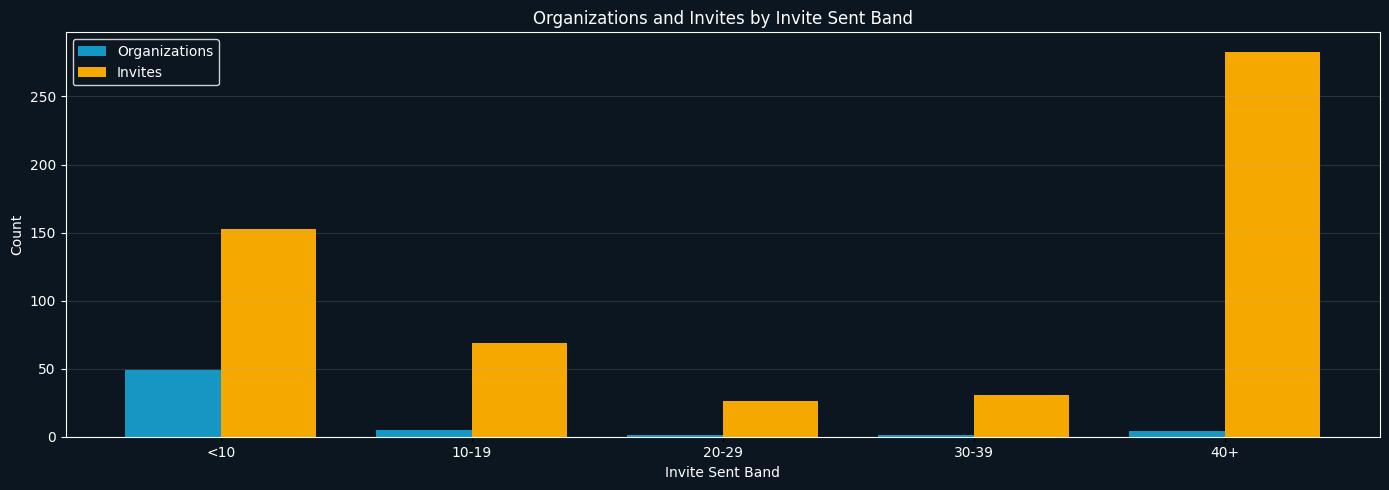

In [0]:
%python
df = spark.sql("""
with org_invites as (
  select
    org_id,
    sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
),
banded_org_events as (
  select
    org_id,
    invite_sent,
    case
      when invite_sent >= 0 and invite_sent <= 9 then '<10'
      when invite_sent >= 10 and invite_sent <= 19 then '10-19'
      when invite_sent >= 20 and invite_sent <= 29 then '20-29'
      when invite_sent >= 30 and invite_sent <= 39 then '30-39'
      when invite_sent >= 40 then '40+'
      else null
    end as invite_sent_band
  from org_invites
)

select
  invite_sent_band,
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites
from banded_org_events
group by invite_sent_band
""").toPandas()

invite_sent_band_order = ['<10', '10-19', '20-29', '30-39', '40+']

df_full = df.set_index('invite_sent_band').reindex(invite_sent_band_order, fill_value=0).reset_index()

x = np.arange(len(df_full['invite_sent_band']))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(x - width/2, df_full['total_orgs'], width, label='Organizations', color='#1696c3')
ax.bar(x + width/2, df_full['total_invites'], width, label='Invites', color='#f5a800')

ax.set_xlabel('Invite Sent Band', color='white')
ax.set_ylabel('Count', color='white')
ax.set_title('Organizations and Invites by Invite Sent Band', color='white')

ax.set_xticks(x)
ax.set_xticklabels(df_full['invite_sent_band'], color='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)
ax.legend(facecolor='#0b1620', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

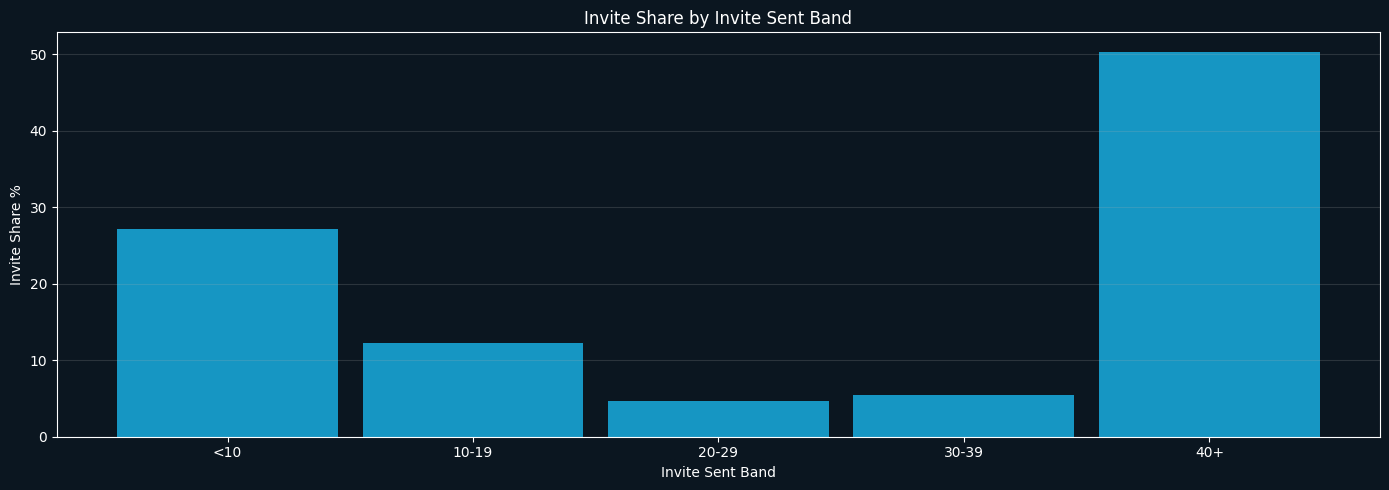

In [0]:
%python
df = spark.sql("""
with org_invites as (
  select
    org_id,
    sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
),
banded_org_events as (
  select
    org_id,
    invite_sent,
    case
      when invite_sent >= 0 and invite_sent <= 9 then '<10'
      when invite_sent >= 10 and invite_sent <= 19 then '10-19'
      when invite_sent >= 20 and invite_sent <= 29 then '20-29'
      when invite_sent >= 30 and invite_sent <= 39 then '30-39'
      when invite_sent >= 40 then '40+'
      else null
    end as invite_sent_band
  from org_invites
)

select
  invite_sent_band,
  round((sum(invite_sent) * 100.0 / sum(sum(invite_sent)) over()),2) as invite_share
from banded_org_events
group by invite_sent_band
""").toPandas()

invite_sent_band_order = ['<10', '10-19', '20-29', '30-39', '40+']

df_full = df.set_index('invite_sent_band').reindex(invite_sent_band_order, fill_value=0).reset_index()

df_full.columns = ['invite_sent_band', 'invite_share']

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df_full['invite_sent_band'], df_full['invite_share'], width=0.9, color='#1696c3')

ax.set_xlabel('Invite Sent Band', color='white')
ax.set_ylabel('Invite Share %', color='white')
ax.set_title('Invite Share by Invite Sent Band', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [0]:
with org_invites as (
  select
    org_id,
    sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
),
banded_org_events as (
  select
    org_id,
    invite_sent
  from org_invites
)

select
  invite_sent,
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites,
  round((sum(invite_sent) * 100.0 / sum(sum(invite_sent)) over()),2) as invite_share,
  min(invite_sent) as min_invite_sent,
  max(invite_sent) as max_invite_sent,
  round(avg(invite_sent),2) as avg_invite_sent,
  round(stddev_samp(invite_sent),2) as stddev_invite_sent
from banded_org_events
group by invite_sent
order by invite_sent

invite_sent,total_orgs,total_invites,invite_share,min_invite_sent,max_invite_sent,avg_invite_sent,stddev_invite_sent
0,4,0,0.00,0,0,0.0,0.0
1,7,7,1.25,1,1,1.0,0.0
2,8,16,2.85,2,2,2.0,0.0
3,9,27,4.80,3,3,3.0,0.0
4,9,36,6.41,4,4,4.0,0.0
5,7,35,6.23,5,5,5.0,0.0
6,3,18,3.20,6,6,6.0,0.0
7,2,14,2.49,7,7,7.0,0.0
11,1,11,1.96,11,11,11.0,null
12,2,24,4.27,12,12,12.0,0.0


Databricks visualization. Run in Databricks to view.

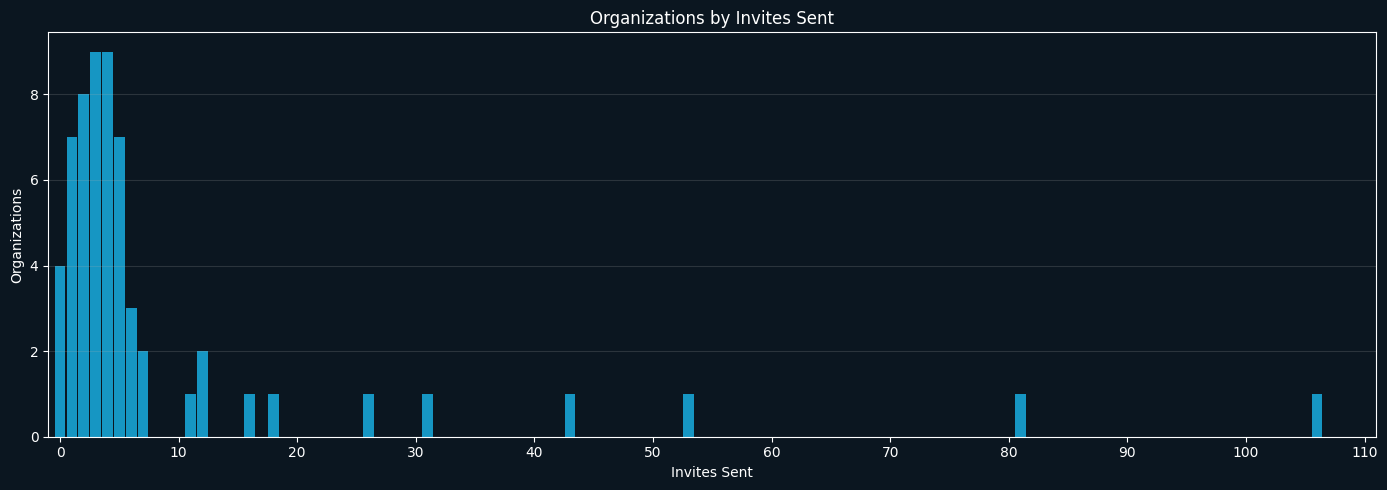

In [0]:
%python
df = spark.sql("""
with org_invites as (
  select
    org_id,
    sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
),
banded_org_events as (
  select
    org_id,
    invite_sent
  from org_invites
)

select
  invite_sent,
  count(distinct org_id) as total_orgs
from banded_org_events
group by invite_sent
order by invite_sent
""").toPandas()

x_labels = list(range(0, df['invite_sent'].max() + 1))

df_full = df.set_index('invite_sent').reindex(x_labels, fill_value=0).reset_index()

df_full.columns = ['invite_sent', 'total_orgs',]

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df_full['invite_sent'], df_full['total_orgs'], width=0.9, color='#1696c3')

ax.set_xlabel('Invites Sent', color='white')
ax.set_ylabel('Organizations', color='white')
ax.set_title('Organizations by Invites Sent', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_xlim(-1, 111)
ax.set_xticks(range(0,111,10))

plt.tight_layout()
plt.show()

Initial Thoughts:
- Over 80% of our customers have invited 7 or fewer team mates.
- 4 organizations account for over half of all invites sent out. Big variation within those 4 as well.
- Need to compare this to organization_size_band from Orgs table 


In [0]:
with org_invites as (
  select
  org_id,
  sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent
  from clean_events_2026_jan
  group by org_id
),

org_sizes as(
  select
  o.org_id,
  organization_size_band,
  invite_sent
  from clean_orgs_2026_jan o
  left join org_invites i
    on o.org_id = i.org_id
)

select
  organization_size_band,
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites,
  round((sum(invite_sent) * 100.0 / sum(sum(invite_sent)) over()),2) as invite_share,
  min(invite_sent) as min_invite_sent,
  max(invite_sent) as max_invite_sent,
  round(avg(invite_sent),2) as avg_invite_sent,
  round(stddev_samp(invite_sent),2) as stddev_invite_sent
from org_sizes
group by organization_size_band
order by case
    when organization_size_band = '1' then 1
    when organization_size_band = '2-5' then 2
    when organization_size_band = '6-20' then 3
    when organization_size_band = '21-100' then 4
    when organization_size_band = '101-500' then 5
    when organization_size_band = '501+' then 6
    else null
  end

organization_size_band,total_orgs,total_invites,invite_share,min_invite_sent,max_invite_sent,avg_invite_sent,stddev_invite_sent
1,13,14,2.49,0,3,1.08,0.95
2-5,22,82,14.59,1,7,3.73,1.61
6-20,10,56,9.96,2,12,5.6,3.31
21-100,11,191,33.99,3,53,17.36,16.89
101-500,3,113,20.11,1,81,37.67,40.41
501+,1,106,18.86,106,106,106.0,null


This feels like a clearer picture of our customer base's invite patterns.
- Invites increase slowly at first, then break through in the 21-100 range and start growing rapidly.
- We have a large number of small teams (2-5) who have a solid share of the total invites given the size of their organizations.
- Invite share is low in lower mid-market (6-20), but increases really well for more established mid-market (21-100).
- 3 of our enterprise organizations have 20% invite share, while our largest enterprise customer alone has 19%. Super high concentration at the top.

Questions:
- What causes the 6-20 band to decline so heavily?
- How do solo teams have any invites?

In [0]:
with org_events as (
  select
  org_id,
  sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent,
  sum(case when event_type = 'user_joined' then 1 else 0 end) as invite_accepted
  from clean_events_2026_jan
  group by org_id
)

select
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites,
  sum(invite_accepted) as total_accepted,
  min(invite_accepted) as min_accepted,
  max(invite_accepted) as max_accepted,
  round((avg(invite_accepted)),2) as avg_accepted,
  round(stddev_samp(invite_accepted),2) as stddev_accepted
from org_events

total_orgs,total_invites,total_accepted,min_accepted,max_accepted,avg_accepted,stddev_accepted
60,562,507,0,103,8.45,18.09


8.45 average against 9.37 sent. I want to see it side-by-side with invites sent

In [0]:
with org_events as (
  select
  org_id,
  sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent,
  sum(case when event_type = 'user_joined' then 1 else 0 end) as invite_accepted
  from clean_events_2026_jan
  group by org_id
),

org_sizes as(
  select
  o.org_id,
  organization_size_band,
  invite_sent,
  invite_accepted
  from clean_orgs_2026_jan o
  left join org_events i
    on o.org_id = i.org_id
)

select
  organization_size_band,
  count(distinct org_id) as total_orgs,
  sum(invite_sent) as total_invites,
  sum(invite_accepted) as total_accepted,
  round(sum(invite_accepted)*100.0 / sum(invite_sent),2) as acceptance_rate,
  round((sum(invite_sent) * 100.0 / sum(sum(invite_sent)) over()),2) as invite_share,
  round((sum(invite_accepted) * 100.0 / sum(sum(invite_accepted)) over()),2) as accepted_share,
  min(invite_accepted) as min_accepted,
  max(invite_accepted) as max_accepted,
  round(avg(invite_sent),2) as avg_invite_sent,
  round((avg(invite_accepted)),2) as avg_accepted,
  round(stddev_samp(invite_accepted),2) as stddev_accepted
from org_sizes
group by organization_size_band
order by case
    when organization_size_band = '1' then 1
    when organization_size_band = '2-5' then 2
    when organization_size_band = '6-20' then 3
    when organization_size_band = '21-100' then 4
    when organization_size_band = '101-500' then 5
    when organization_size_band = '501+' then 6
    else null
  end

organization_size_band,total_orgs,total_invites,total_accepted,acceptance_rate,invite_share,accepted_share,min_accepted,max_accepted,avg_invite_sent,avg_accepted,stddev_accepted
1,13,14,7,50.00,2.49,1.38,0,2,1.08,0.54,0.66
2-5,22,82,67,81.71,14.59,13.21,1,5,3.73,3.05,1.29
6-20,10,56,48,85.71,9.96,9.47,2,12,5.6,4.8,3.68
21-100,11,191,169,88.48,33.99,33.33,2,45,17.36,15.36,15.06
101-500,3,113,113,100.00,20.11,22.29,1,81,37.67,37.67,40.41
501+,1,106,103,97.17,18.86,20.32,103,103,106.0,103.0,null


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

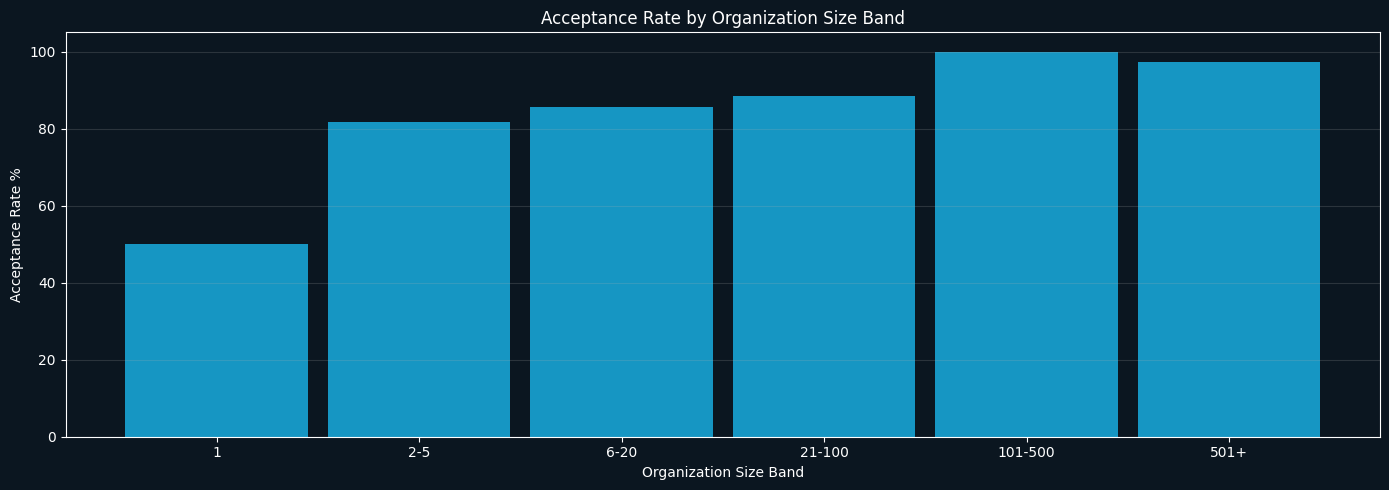

In [0]:
%python
df = spark.sql("""
with org_events as (
  select
  org_id,
  sum(case when event_type = 'user_invited' then 1 else 0 end) as invite_sent,
  sum(case when event_type = 'user_joined' then 1 else 0 end) as invite_accepted
  from clean_events_2026_jan
  group by org_id
),

org_sizes as(
  select
  o.org_id,
  organization_size_band,
  invite_sent,
  invite_accepted
  from clean_orgs_2026_jan o
  left join org_events i
    on o.org_id = i.org_id
)

select
  organization_size_band,
  round(sum(invite_accepted)*100.0 / sum(invite_sent),2) as acceptance_rate
from org_sizes
group by organization_size_band
order by case
    when organization_size_band = '1' then 1
    when organization_size_band = '2-5' then 2
    when organization_size_band = '6-20' then 3
    when organization_size_band = '21-100' then 4
    when organization_size_band = '101-500' then 5
    when organization_size_band = '501+' then 6
    else null
  end
""").toPandas()

organization_size_band_order = ['1', '2-5', '6-20', '21-100', '101-500', '501+']

df_full = df.set_index('organization_size_band').reindex(organization_size_band_order, fill_value=0).reset_index()

df_full.columns = ['organization_size_band', 'acceptance_rate']

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df_full['organization_size_band'], df_full['acceptance_rate'], width=0.9, color='#1696c3')

ax.set_xlabel('Organization Size Band', color='white')
ax.set_ylabel('Acceptance Rate %', color='white')
ax.set_title('Acceptance Rate by Organization Size Band', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

Okay, going from small (2-5) to established mid-market (21-100) has ~4% growth in acceptance rate each step, while enterprise jumps to almost 100% acceptance rate accross both bands. As organizations grow, they are more likely to have their invites accepted. This may be due to better rollout or training systems, clearer need for collaboration, or higher urgency around usage.

The individual companies (1) are very different. This is screaming test accounts to me.

In [0]:
with first_invite as (
  select
  org_id,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from clean_events_2026_jan
  group by org_id
),

org_invite_timing as (
  select
  org_id,
  signup_timestamp,
  first_invite_timestamp,
  date_diff(minute, signup_timestamp, first_invite_timestamp) as minutes_to_first_invite
  from first_invite
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  round(avg(minutes_to_first_invite) / 60.0,2) as avg_hours,
  percentile_approx(minutes_to_first_invite, 0.5) / 60.0 as median_hours,
  percentile_approx(minutes_to_first_invite, 0.75) / 60.0 as p75_hours,
  round(sum(case when minutes_to_first_invite <= 60 then 1 else 0 end) * 100.0 / count(*),2) as first_invite_within_hour,
  round(sum(case when minutes_to_first_invite <= 1440 then 1 else 0 end) * 100.0 / count(*),2) as first_invite_within_24h,
  round(sum(case when minutes_to_first_invite <= 4320 then 1 else 0 end) * 100.0 / count(*),2) as first_invite_within_72h,
  round(sum(case when minutes_to_first_invite <= 10080 then 1 else 0 end) * 100.0 / count(*),2) as first_invite_within_7d
from org_invite_timing

avg_hours,median_hours,p75_hours,first_invite_within_hour,first_invite_within_24h,first_invite_within_72h,first_invite_within_7d
303.75,175.950000,441.800000,0.00,8.93,25.00,48.21


Wow, bigger delay than I thought. I would have expected more invites to come through in the initial hour than in the time between 72 hours and 7 days, just because it is part of the onboarding flow.

Is it not a part of the onboarding flow anymore?!

In over 90% of new accounts, the creator doesn't invite anyone until the following day, and 75% are waiting over three days and over half have not invited anyone within the first week. That is a serious concern.

It could be that sysadmins are logging in, testing the platform, and getting things set up for their team. Even accounting for setup time, I would expect faster operational readiness, especially for the 2-5 size band, since deployment complexity should be low.

Collaboration is a core driver of our platform's value. Delays in invites slow time-to-value, and need to be reduced.

Recommended Next Steps:
- Investigate friction between sign up and operational readiness. 
- Test adding invites back as a part of onboarding again if it has been removed.
- Review marketing content and pre-sale education resources to make sure new customers can move from sign up to collaboration more quickly.

#####Onboarding

Since we we just looking at the time-to-invite and potential concerns from onboarding, lets look at onboarding penetration for new organizations.

Questions to answer:
- How many new Organizations complete the onboarding process?
- How often do new Organizations abandon onboarding?
- How quickly do Organizations complete onboarding?
- How soon after sign up does onboarding begin?

In [0]:
with org_onboarding as (
  select
  org_id,
  max(case when event_type = 'onboarding_started' then 1 else 0 end) as started_onboarding,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from clean_events_2026_jan
  group by org_id
)

select
  count(distinct org_id) as total_orgs,
  sum(started_onboarding) as orgs_started_onboarding,
  round(sum(started_onboarding) * 100.0 / count(distinct org_id),2) as all_orgs_started_onboarding,
  sum(completed_onboarding) as orgs_completed_onboarding,
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as all_orgs_completed_onboarding,
  round(sum(completed_onboarding) * 100.0 / nullif(sum(started_onboarding),0),2) as orgs_completed_onboarding,
  sum(abandoned_onboarding) as orgs_abandoned_onboarding,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as all_orgs_abandoned_onboarding,
  round(sum(abandoned_onboarding) * 100.0 / nullif(sum(started_onboarding),0),2) as orgs_abandoned_onboarding
from org_onboarding

total_orgs,orgs_started_onboarding,all_orgs_started_onboarding,orgs_completed_onboarding,all_orgs_completed_onboarding,orgs_completed_onboarding,orgs_abandoned_onboarding,all_orgs_abandoned_onboarding,orgs_abandoned_onboarding
60,47,78.33,23,38.33,48.94,16,26.67,34.04


78% of orgs start onboarding, but only half of those (38%) complete it. Initial penetration is pretty good for an optional onboarding experience, but the dropoff means we have too much friction, or they may have steps they want to skip until later.

34% of all organizations that start onboarding abandon it at some point. They may re-start later, or they may never return to the onboarding flow.

In [0]:
with onboarding_events as (
  select
  org_id,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from clean_events_2026_jan
  group by org_id
),

onboarding_timing as (
  select
  org_id,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) as minutes_to_complete_onboarding
  from onboarding_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  round(avg(minutes_to_complete_onboarding) / 60.0,2) as avg_hours,
  percentile_approx(minutes_to_complete_onboarding, 0.5) / 60.0 as median_hours,
  percentile_approx(minutes_to_complete_onboarding, 0.75) / 60.0 as p75_hours,
  round(sum(case when minutes_to_complete_onboarding <= 60 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_completed_within_hour,
  round(sum(case when minutes_to_complete_onboarding <= 1440 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_completed_within_24h,
  round(sum(case when minutes_to_complete_onboarding <= 4320 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_completed_within_72h,
  round(sum(case when minutes_to_complete_onboarding <= 10080 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_completed_within_7d
from onboarding_timing

avg_hours,median_hours,p75_hours,onboarding_completed_within_hour,onboarding_completed_within_24h,onboarding_completed_within_72h,onboarding_completed_within_7d
1.4,0.983333,2.366667,52.17,100.00,100.00,100.00


Onboarding takes nearly an hour for the median users. Either we have a major issue in the onboarding process, or users frequently complete onboarding in multiple seperate sittings. This does explain why invites would take longer than expected. If invites are sent out after onboarding and onboarding often takes 2 hours or more to complete, then invites would be heavily dealyed.

Lets look at when invites are sent in relation to onboarding.

In [0]:
with onboarding_invites as (
  select
  org_id,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from clean_events_2026_jan
  group by org_id
),

invite_timing as (
  select
  org_id,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  first_invite_timestamp,
  case
    when first_invite_timestamp is null then 'No invite'
    when onboarding_started_timestamp is null then 'Invite no Onboarding'
    when first_invite_timestamp < onboarding_started_timestamp then 'Invite Before Onboarding Start'
    when onboarding_completed_timestamp is null and first_invite_timestamp >= onboarding_started_timestamp then 'Invite After Start No Complete'
    when first_invite_timestamp >= onboarding_started_timestamp and first_invite_timestamp <= onboarding_completed_timestamp then 'Invite Between Onboarding Start and End'
    when first_invite_timestamp > onboarding_completed_timestamp then 'Invite After Onboarding'
    else 'unclassified'
  end as invite_timing_bucket,
  case
    when onboarding_started_timestamp is not null and first_invite_timestamp is not null
      then date_diff(minute, onboarding_started_timestamp, first_invite_timestamp)
    else null
  end as minutes_from_start_to_first_invite,
  case
    when onboarding_completed_timestamp is not null and first_invite_timestamp is not null
      then date_diff(minute, onboarding_completed_timestamp, first_invite_timestamp)
    else null
  end as minutes_from_complete_to_first_invite
  from onboarding_invites
)

select
  invite_timing_bucket,
  count(*) as total_orgs,
  round(count(*) * 100.0 / sum(count(*)) over (),2) as share_orgs
from invite_timing
group by invite_timing_bucket
order by case
  when invite_timing_bucket = 'Invite Before Onboarding Start' then 1
  when invite_timing_bucket = 'Invite Between Onboarding Start and End' then 2
  when invite_timing_bucket = 'Invite After Start No Complete' then 3
  when invite_timing_bucket = 'Invite After Onboarding' then 4
  when invite_timing_bucket = 'Invite no Onboarding' then 5
  when invite_timing_bucket = 'No invite' then 6
  else 7
end

invite_timing_bucket,total_orgs,share_orgs
Invite Between Onboarding Start and End,1,1.67
Invite After Start No Complete,21,35.00
Invite After Onboarding,21,35.00
Invite no Onboarding,13,21.67
No invite,4,6.67


No organizations sent invites before starting onboarding. 71% of new organizations send their first invite after onboarding had begun, while 21% sent invites without ever starting onboarding.

Onboarding is not acting as a prerequisite for sending invites, but does drive invite behaviour for most users.

The Invite After Start No Complete bucket is interesting. 35% of new organizations start onboarding, begin sending invites, but never return to the onboarding process. This provides context to why onboarding may be abandoned so frequently. Onboarding drives collaboration, collaboration is the key value our platform provides, and once it is being delivered they abandon onboarding because it got them where they needed to be to start realizing value from the platform.

Before doing a write-up on onboarding, I want to look at onboarding start timing explicitly just to see how big of a delay there is between sign up and onboarding start.

In [0]:
with startup_events as (
  select
  org_id,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as user_signed_up_timestamp,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp
  from clean_events_2026_jan
  group by org_id
),

onboarding_timing as (
  select
  org_id,
  user_signed_up_timestamp,
  onboarding_started_timestamp,
  date_diff(minute, user_signed_up_timestamp, onboarding_started_timestamp) as minutes_to_start_onboarding
  from startup_events
  where user_signed_up_timestamp is not null and onboarding_started_timestamp is not null
)

select
  round(avg(minutes_to_start_onboarding) / 60.0,2) as avg_hours,
  percentile_approx(minutes_to_start_onboarding, 0.5) / 60.0 as median_hours,
  percentile_approx(minutes_to_start_onboarding, 0.75) / 60.0 as p75_hours,
  round(sum(case when minutes_to_start_onboarding <= 60 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_started_within_hour,
  round(sum(case when minutes_to_start_onboarding <= 1440 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_started_within_24h,
  round(sum(case when minutes_to_start_onboarding <= 4320 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_started_within_72h,
  round(sum(case when minutes_to_start_onboarding <= 10080 then 1 else 0 end) * 100.0 / count(*),2) as onboarding_started_within_7d
from onboarding_timing

avg_hours,median_hours,p75_hours,onboarding_started_within_hour,onboarding_started_within_24h,onboarding_started_within_72h,onboarding_started_within_7d
2.09,2.166667,2.833333,19.15,100.00,100.00,100.00


Organizations that start onboarding usually start around 2 hours after sign up, and all users who start onboarding do so in the first day. Only 19% of organizations that start onboarding do so in the first hour, meaning onboarding is not viewed as immediately valuable for a majority of new organizations.

This suggests many new admin prefer to look around independently before starting the onboarding process.
It may also indicate that onboarding does not appear to be important or valuable to new users.

One concern would be if they start investigating the platform, hit a wall, and go to onboarding to break through it. This would mean onboarding is serving as a means to overcome friction or overwhelm, rather than a starting point for smooth activation.

Recommended Next Steps:
- Investigate why time to complete onboarding is longer than expected.
- Identify causes for onboarding abndonment or potential sources of friction within onboarding experience.
- We need more data around new user experience for new organizations within their first few hours. Check with engineering on what is available, session recordings, heatmaps, click paths, etc.
- Test a more structured, non-skippable onboarding experience in relation to time to invite and time to core product usage (only after onboarding length is investigated)

#####Core Product Usage

I want to know how much each product feature is being used.

Questions to answer:
- How many repos do orgs create?
- How long after signup do they have their first collaboration event?
- How many commits, comments, and pull requests created / merged do new organizations have?

In [0]:
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
)

select
  count(*) as total_orgs,
  sum(repos_created) as total_repos_created,
  min(repos_created) as min_repos_created,
  max(repos_created) as max_repos_created,
  round(avg(repos_created),2) as avg_repos_created,
  round(stddev_samp(repos_created),2) as stddev_repos_created,
  round(sum(case when repos_created = 0 then 1 else 0 end) * 100.0 / count(*),2) as zero_repos,
  round(sum(case when repos_created >= 1 then 1 else 0 end) * 100.0 / count(*),2) as one_plus_repos,
  round(sum(case when repos_created >= 5 then 1 else 0 end) * 100.0 / count(*),2) as five_plus_repos,
  round(sum(case when repos_created >= 10 then 1 else 0 end) * 100.0 / count(*),2) as ten_plus_repos
from org_repo_counts

total_orgs,total_repos_created,min_repos_created,max_repos_created,avg_repos_created,stddev_repos_created,zero_repos,one_plus_repos,five_plus_repos,ten_plus_repos
60,278,0,58,4.63,10.26,28.33,71.67,20.00,11.67


28% of new organizations have not created their first repository, with most organizations (51%) creating between 1 and 4 repos inclusive. Very wide spread, average is very driven by some high-use organizations. I want to band these out and see the distribution.

In [0]:
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
)

select
  repos_created,
  count(*) as total_orgs,
  round(count(*) * 100.0 / sum(count(*)) over (),2) as org_share,
  round(sum(repos_created) * 100.0 / sum(sum(repos_created)) over (),2) as repo_share
from org_repo_counts
group by repos_created
order by repos_created

repos_created,total_orgs,org_share,repo_share
0,17,28.33,0.00
1,16,26.67,5.76
2,6,10.00,4.32
3,6,10.00,6.47
4,3,5.00,4.32
5,3,5.00,5.40
9,2,3.33,6.47
10,2,3.33,7.19
11,1,1.67,3.96
25,1,1.67,8.99


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

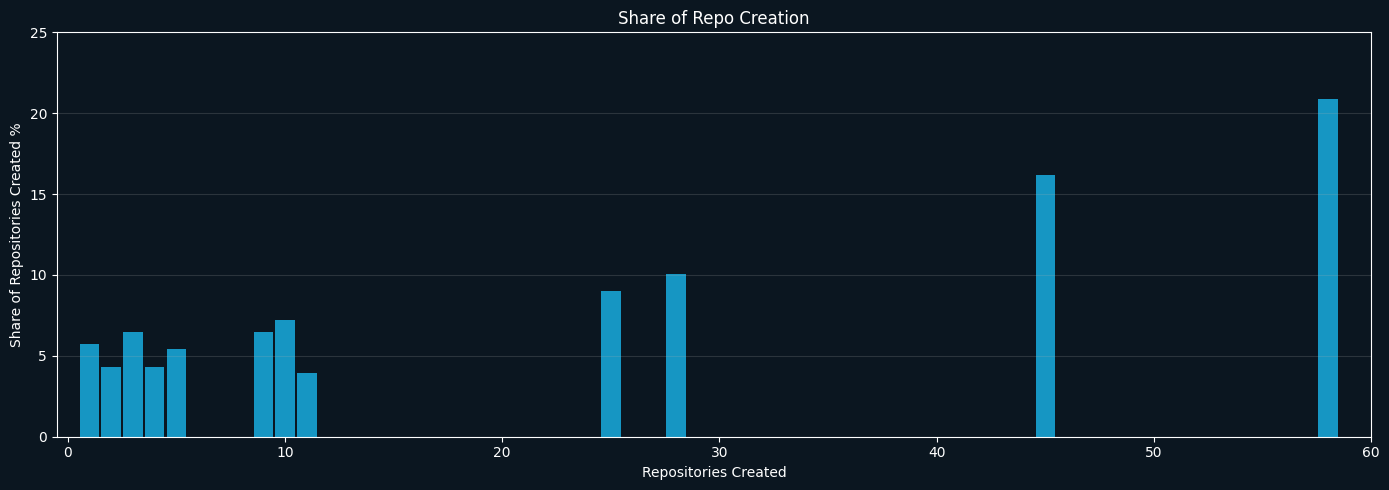

In [0]:
%python
df = spark.sql("""
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
)

select
  repos_created,
  round(sum(repos_created) * 100.0 / sum(sum(repos_created)) over (),2) as repo_share
from org_repo_counts
group by repos_created
order by repos_created
""").toPandas()

x_labels = list(range(0, df['repos_created'].max() + 1))

df_full = df.set_index('repos_created').reindex(x_labels, fill_value=0).reset_index()

df_full.columns = ['repos_created', 'repo_share',]

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df_full['repos_created'], df_full['repo_share'], width=0.9, color='#1696c3')

ax.set_xlabel('Repositories Created', color='white')
ax.set_ylabel('Share of Repositories Created %', color='white')
ax.set_title('Share of Repo Creation', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_xlim(-0.5, df_full['repos_created'].max() + 2)
ax.set_xticks(range(0,df_full['repos_created'].max()+3,10))

ax.set_ylim(0, df_full['repo_share'].max() + 2)
ax.set_yticks(range(0,26,5))

plt.tight_layout()
plt.show()

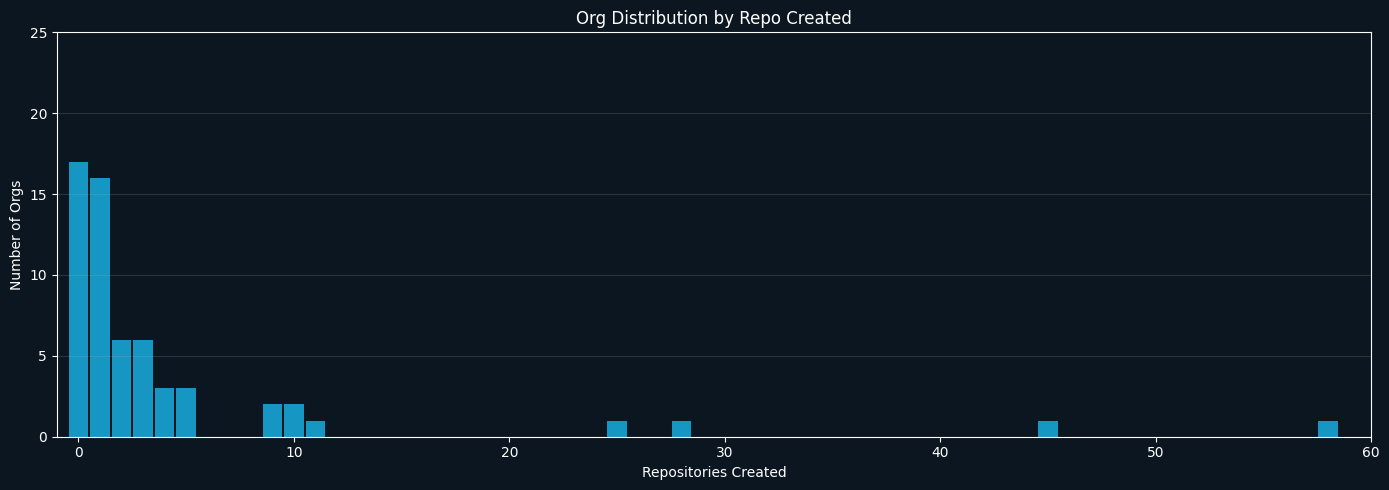

In [0]:
%python
df = spark.sql("""
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
)

select
  repos_created,
  count(*) as total_orgs
from org_repo_counts
group by repos_created
order by repos_created
""").toPandas()

x_labels = list(range(0, df['repos_created'].max() + 1))

df_full = df.set_index('repos_created').reindex(x_labels, fill_value=0).reset_index()

df_full.columns = ['repos_created', 'total_orgs',]

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df_full['repos_created'], df_full['total_orgs'], width=0.9, color='#1696c3')

ax.set_xlabel('Repositories Created', color='white')
ax.set_ylabel('Number of Orgs', color='white')
ax.set_title('Org Distribution by Repo Created', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_xlim(-1, df_full['repos_created'].max() + 2)
ax.set_xticks(range(0,df_full['repos_created'].max()+3,10))

ax.set_ylim(0, df_full['total_orgs'].max() + 2)
ax.set_yticks(range(0,26,5))

plt.tight_layout()
plt.show()

That's clearer. 28% of organizations have no repositories, and 26% of organizations have only 1 repo. A single high-use organizations has created 20% of all repos, and the top 15% of organizations by repo creation account for over 73% of all repositories created.

Very top heavy distribution, may have an issue getting smaller organizations to value.

In [0]:
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
),

ranked_orgs as (
  select
  org_id,
  repos_created,
  row_number() over (order by repos_created desc, org_id) as org_rank,
  sum(repos_created) over (order by repos_created desc, org_id rows between unbounded preceding and current row) as cumulative_repos_created,
  sum(repos_created) over () as total_repos_created
  from org_repo_counts
)

select
  org_rank,
  org_id,
  repos_created,
  cumulative_repos_created,
  round(cumulative_repos_created * 100.0 / total_repos_created,2) as cumulative_repo_share
from ranked_orgs
order by org_rank

org_rank,org_id,repos_created,cumulative_repos_created,cumulative_repo_share
1,org_100032,58,58,20.86
2,org_100047,45,103,37.05
3,org_100007,28,131,47.12
4,org_100024,25,156,56.12
5,org_100012,11,167,60.07
6,org_100051,10,177,63.67
7,org_100053,10,187,67.27
8,org_100005,9,196,70.50
9,org_100014,9,205,73.74
10,org_100019,5,210,75.54


Databricks visualization. Run in Databricks to view.

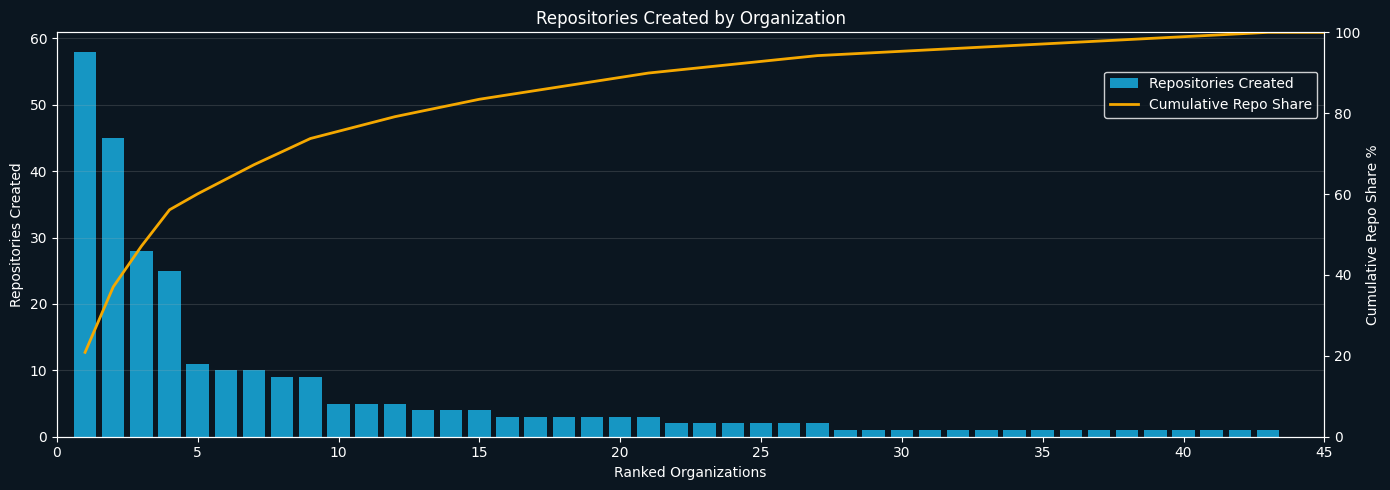

In [0]:
%python
df = spark.sql("""
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
),

ranked_orgs as (
  select
  org_id,
  repos_created,
  row_number() over (order by repos_created desc, org_id) as org_rank,
  sum(repos_created) over (order by repos_created desc, org_id rows between unbounded preceding and current row) as cumulative_repos_created,
  sum(repos_created) over () as total_repos_created
  from org_repo_counts
)

select
  org_rank,
  org_id,
  repos_created,
  cumulative_repos_created,
  round(cumulative_repos_created * 100.0 / total_repos_created,2) as cumulative_repo_share
from ranked_orgs
order by org_rank
""").toPandas()

fig, ax1 = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax1.set_facecolor('#0b1620')

ax1.bar(
  df['org_rank'],
  df['repos_created'],
  color='#1696c3',
  label='Repositories Created'
)

ax1.set_xlabel('Ranked Organizations', color='white')
ax1.set_ylabel('Repositories Created', color='white')
ax1.set_title('Repositories Created by Organization', color='white')
ax1.tick_params(axis='x', colors='white')
ax1.tick_params(axis='y', colors='white')

ax2 = ax1.twinx()

ax2.plot(
  df['org_rank'],
  df['cumulative_repo_share'],
  color='#f5a800',
  linewidth=2,
  label='Cumulative Repo Share'
)

ax2.set_ylabel('Cumulative Repo Share %', color='white')
ax2.set_ylim(0,100)
ax2.tick_params(axis='y', colors='white')

for spine in ax1.spines.values():
  spine.set_color('white')

for spine in ax2.spines.values():
  spine.set_color('white')

ax1.grid(axis='y', alpha=0.2)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
  lines_1 + lines_2,
  labels_1 + labels_2,
  loc='upper right',
  bbox_to_anchor=(1, 0.92),
  facecolor='#0b1620',
  edgecolor='white',
  labelcolor='white'
)

ax1.set_xlim(0.5, 45)
ax1.set_xticks(range(0, 46, 5))

plt.tight_layout()
plt.show()

In [0]:
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
),

org_repo_size as (
  select
  o.organization_size_band,
  o.org_id,
  coalesce(r.repos_created,0) as repos_created
  from clean_orgs_2026_jan o
  left join org_repo_counts r
    on o.org_id = r.org_id
)

select
  organization_size_band,
  count(*) as total_orgs,
  sum(repos_created) as total_repos_created,
  round(sum(repos_created) * 100.0 / sum(sum(repos_created)) over (),2) as repo_share,
  round(avg(repos_created),2) as avg_repos_created,
  percentile_approx(repos_created, 0.5) as median_repos_created,
  percentile_approx(repos_created, 0.75) as p75_repos_created,
  round(sum(case when repos_created = 0 then 1 else 0 end) * 100.0 / count(*),2) as pct_zero_repos,
  max(repos_created) as max_repos_created
from org_repo_size
group by organization_size_band
order by case
  when organization_size_band = '1' then 1
  when organization_size_band = '2-5' then 2
  when organization_size_band = '6-20' then 3
  when organization_size_band = '21-100' then 4
  when organization_size_band = '101-500' then 5
  when organization_size_band = '501+' then 6
  else 7
end

organization_size_band,total_orgs,total_repos_created,repo_share,avg_repos_created,median_repos_created,p75_repos_created,pct_zero_repos,max_repos_created
1,13,11,3.96,0.85,1,1,38.46,3
2-5,22,32,11.51,1.45,1,2,36.36,5
6-20,10,30,10.79,3.0,2,4,10.00,10
21-100,11,93,33.45,8.45,4,11,18.18,28
101-500,3,54,19.42,18.0,9,45,33.33,45
501+,1,58,20.86,58.0,58,58,0.00,58


Databricks visualization. Run in Databricks to view.

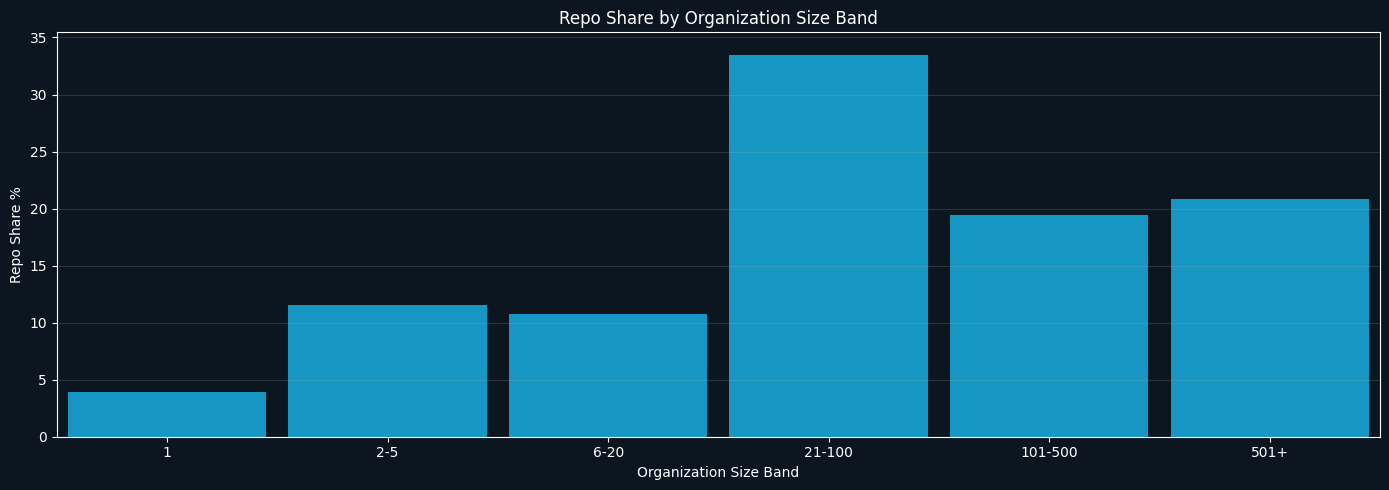

In [0]:
%python
df = spark.sql("""
with org_repo_counts as (
  select
  org_id,
  sum(case when event_type = 'repo_created' then 1 else 0 end) as repos_created
  from clean_events_2026_jan
  group by org_id
),

org_repo_size as (
  select
  o.organization_size_band,
  o.org_id,
  coalesce(r.repos_created,0) as repos_created
  from clean_orgs_2026_jan o
  left join org_repo_counts r
    on o.org_id = r.org_id
)

select
  organization_size_band,
  round(sum(repos_created) * 100.0 / sum(sum(repos_created)) over (),2) as repo_share
from org_repo_size
group by organization_size_band
""").toPandas()

organization_size_band_order = ['1', '2-5', '6-20', '21-100', '101-500', '501+']

df_full = df.set_index('organization_size_band').reindex(organization_size_band_order, fill_value=0).reset_index()

df_full.columns = ['organization_size_band', 'repo_share']

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df_full['organization_size_band'], df_full['repo_share'], width=0.9, color='#1696c3')

ax.set_xlabel('Organization Size Band', color='white')
ax.set_ylabel('Repo Share %', color='white')
ax.set_title('Repo Share by Organization Size Band', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_xlim(-0.5, len(x_labels)-0.5)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(organization_size_band_order, color='white')

ax.set_ylim(0, df_full['repo_share'].max() + 2)
ax.set_yticks(range(0, int(df_full['repo_share'].max())+3, 5))

plt.tight_layout()
plt.show()

Repo creation scales well with organization size, really hitting its stride in the established mid-market group (21-100). Small teams (2-5) have very shallow product usage, 36% of them have no repos and most have only 1. This is our largest band by total orgs.

The small mid-market band (6-20) is again an opportunity point. They are more engaged than the small teams, but not significantly so. This may suggest that once organizations move from small team to small mid-market, complexity scaling begins to outpace headcount scaling, which only starts to level off again somewhere in the established mis-market band.

In [0]:
with collaboration_events as (
  select
  org_id,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from clean_events_2026_jan
  group by org_id
),

collaboration_timing as (
  select
  org_id,
  signup_timestamp,
  first_collaboration_timestamp,
  date_diff(minute, signup_timestamp, first_collaboration_timestamp) as minutes_to_first_collaboration
  from collaboration_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  round(avg(minutes_to_first_collaboration) / 60.0,2) as avg_hours,
  percentile_approx(minutes_to_first_collaboration, 0.5) / 60.0 as median_hours,
  percentile_approx(minutes_to_first_collaboration, 0.75) / 60.0 as p75_hours,
  round(sum(case when minutes_to_first_collaboration <= 60 then 1 else 0 end) * 100.0 / count(*),2) as first_collaboration_within_hour,
  round(sum(case when minutes_to_first_collaboration <= 1440 then 1 else 0 end) * 100.0 / count(*),2) as first_collaboration_within_24h,
  round(sum(case when minutes_to_first_collaboration <= 4320 then 1 else 0 end) * 100.0 / count(*),2) as first_collaboration_within_72h,
  round(sum(case when minutes_to_first_collaboration <= 10080 then 1 else 0 end) * 100.0 / count(*),2) as first_collaboration_within_7d
from collaboration_timing

avg_hours,median_hours,p75_hours,first_collaboration_within_hour,first_collaboration_within_24h,first_collaboration_within_72h,first_collaboration_within_7d
708.18,530.783333,977.850000,0.00,0.00,5.26,10.53


Bit of a stomach drop moment. Median of 530 hours or about 22 days to First Collaboration Event. Since this is our first measure of value delivery, that feels way too long. 5% hit FCE in 3 days, and only 10% hit it in 7.

I want to compare this with onboarding completion and see if the current onboarding flow increases time to value

In [0]:
with org_onboarding as (
  select
  org_id,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp,
  min(case when event_type = 'onboarding_abandoned' then event_timestamp else null end) as onboarding_abandoned_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from clean_events_2026_jan
  group by org_id
),

onboarding_groups as (
  select
  org_id,
  signup_timestamp,
  first_collaboration_timestamp,
  case
    when onboarding_started_timestamp is null then 'Never Started Onboarding'
    when onboarding_completed_timestamp is not null then 'Completed Onboarding'
    when onboarding_abandoned_timestamp is not null then 'Abandoned Onboarding'
    else null
  end as onboarding_status,
  case
    when signup_timestamp is not null and first_collaboration_timestamp is not null
      then date_diff(hour, signup_timestamp, first_collaboration_timestamp)
    else null
  end as hours_to_first_collaboration
  from org_onboarding
  where signup_timestamp is not null
)

select
  onboarding_status,
  count(*) as total_orgs,
  sum(case when first_collaboration_timestamp is not null then 1 else 0 end) as orgs_with_fce,
  round(sum(case when first_collaboration_timestamp is not null then 1 else 0 end) * 100.0 / count(*),2) as percent_orgs_with_fce,
  round(avg(hours_to_first_collaboration),2) as avg_hours_to_fce,
  percentile_approx(hours_to_first_collaboration, 0.5) as median_hours_to_fce,
  percentile_approx(hours_to_first_collaboration, 0.75) as p75_hours_to_fce
from onboarding_groups
group by onboarding_status
order by median_hours_to_fce

onboarding_status,total_orgs,orgs_with_fce,percent_orgs_with_fce,avg_hours_to_fce,median_hours_to_fce,p75_hours_to_fce
Abandoned Onboarding,16,16,100.00,601.0,436,775
Completed Onboarding,23,22,95.65,735.18,512,983
Never Started Onboarding,13,12,92.31,810.42,554,933
null,8,7,87.50,689.57,794,1085


Okay, this is interesting.

Abandoned Onboarding have a significantly faster time to FCE than the median (436 vs 530), and every org that abandoned onboarding has a First Collaboration Event. Completed Onboarding is only slight faster than median time to FCE (512 vs 530).

This is almost mirrored in the next two categories. Never Started Onboarding are slightly slower than median time to FCE, and null (those who started, but never abandoned or completed) have significantly slower time to FCE.

This indicates onboarding does drive time to First Collaboration Event, but once organizations reach their First Collaboration Event, completing onboarding becomes a lower priority.

Onboarding is likely useful, but needs improvement and refining. This dovetails into our test hypothesis later, but lets round out the Core Product Usage events.

In [0]:
with org_core_usage as (
  select
  org_id,
  sum(case when event_type = 'commit_pushed' then 1 else 0 end) as commits_pushed,
  sum(case when event_type = 'comment_added' then 1 else 0 end) as comments_added,
  sum(case when event_type = 'pull_request_created' then 1 else 0 end) as pull_requests_created,
  sum(case when event_type = 'pull_request_merged' then 1 else 0 end) as pull_requests_merged
  from clean_events_2026_jan
  group by org_id
),

event_stats as (

  select
  'commit_pushed' as event_type,
  count(*) as total_orgs,
  sum(commits_pushed) as total_events,
  round(avg(commits_pushed),2) as avg_events,
  percentile_approx(commits_pushed, 0.5) as median_events,
  percentile_approx(commits_pushed, 0.75) as p75_events,
  round(sum(case when commits_pushed = 0 then 1 else 0 end) * 100.0 / count(*),2) as pct_zero_events,
  max(commits_pushed) as max_events
  from org_core_usage

  union all

  select
  'comment_added' as event_type,
  count(*) as total_orgs,
  sum(comments_added) as total_events,
  round(avg(comments_added),2) as avg_events,
  percentile_approx(comments_added, 0.5) as median_events,
  percentile_approx(comments_added, 0.75) as p75_events,
  round(sum(case when comments_added = 0 then 1 else 0 end) * 100.0 / count(*),2) as pct_zero_events,
  max(comments_added) as max_events
  from org_core_usage

  union all

  select
  'pull_request_created' as event_type,
  count(*) as total_orgs,
  sum(pull_requests_created) as total_events,
  round(avg(pull_requests_created),2) as avg_events,
  percentile_approx(pull_requests_created, 0.5) as median_events,
  percentile_approx(pull_requests_created, 0.75) as p75_events,
  round(sum(case when pull_requests_created = 0 then 1 else 0 end) * 100.0 / count(*),2) as pct_zero_events,
  max(pull_requests_created) as max_events
  from org_core_usage

  union all

  select
  'pull_request_merged' as event_type,
  count(*) as total_orgs,
  sum(pull_requests_merged) as total_events,
  round(avg(pull_requests_merged),2) as avg_events,
  percentile_approx(pull_requests_merged, 0.5) as median_events,
  percentile_approx(pull_requests_merged, 0.75) as p75_events,
  round(sum(case when pull_requests_merged = 0 then 1 else 0 end) * 100.0 / count(*),2) as pct_zero_events,
  max(pull_requests_merged) as max_events
  from org_core_usage
)

select
event_type,
total_orgs,
total_events,
avg_events,
median_events,
p75_events,
pct_zero_events,
max_events
from event_stats
order by event_type

event_type,total_orgs,total_events,avg_events,median_events,p75_events,pct_zero_events,max_events
comment_added,60,299,4.98,1,3,28.33,76
commit_pushed,60,638,10.63,2,6,23.33,168
pull_request_created,60,294,4.9,1,3,35.00,72
pull_request_merged,60,200,3.33,0,1,56.67,51


Quick insights:
- All core product usage is very top heavy. We have a few high-usage organizations and a large number of shallow usage organizations.
- Most organizations have 3 or less comments. Communication may happen off platform for smaller teams.
- Over half of all organizations have not merged a pull request. Could be a different use case then working together on code projects, and they are instead using the platform for storage? Or smaller organizations don't have as much need for a formal review workflow.
- Over 75% of organizations have pushed a commit, with most having 6 or fewer. Still top heavy, but shows some feature adoption for smaller organizations.
- Basic usage is very common (commits and comments), more advanced collaboration worflows are less common (pull requests).

Recommended Next Steps:
- Reduce delay to first collaboration event.
- Improve onboarding flow's impact on time to first collaboration event.
- We seem to have 4 clear groups: Solo and Small Teams, Small Mid-Market, Established Mid-Market, and Enterprise. Gather feedback on organization needs within those 4 segments to prevent us from being driven by one segments needs. Don't let one band's needds drive product decisions for all.
- Find ways to support the transition from Small Mid-Market to Established Mid-Market. They often showed weaker performance in analysis relative to adjacent bands.
- Create a scorecard for lifecycle events by organization band. Time to FCE, time to invite, time to first repo, total repos created.


#####Section Review

This sectioned focused on understanding more of a customer's journey from sign up to collaborating with their team. New Organizations generally engage with onboarding early, and it serves as an important driver of key collaboration measusres such as invitation timing and Core Product Usage milestones regardless of whether it is completed or not. However, those key collaboration measures are more delayed than I initially expected. We found significant variances by organization size, which is a useful segmentation to use going forward.

Our primary growth opportunity at this stage is to reduce time delay between signup and first collaboration event through an enhanced onboarding structure that emphasizes clear paths to value.